# Exoplanet Habitability Analysis: Supervised Classification and Unsupervised Clustering

## 1. Project Overview & Objectives

### 1.1. Introduction
This notebook studies the habitability potential of confirmed exoplanets using the NASA Exoplanet Archive *Planetary Systems Composite Parameters* table. The aim is to (a) build a classifier that places a planet into a habitability class from its physical and stellar parameters, and (b) check whether unsupervised clustering finds natural groupings in the same data.

### 1.2. Goal: Supervised Classification of Habitability
Train and compare several classifiers, select the best one with stratified cross-validation, tune it and report honest hold-out performance, with a particular focus on the two minority (habitable) classes.

### 1.3. Goal: Unsupervised Clustering Validation
Run K-means and HDBSCAN on the physical parameters and compare the discovered clusters against the habitability labels.

### 1.4. Target Variable Definition (P_HABITABLE)
The label is derived from the archive's insolation flux (`pl_insol`, Earth = 1) and equilibrium temperature (`pl_eqt`, Kelvin):

- **0 – Non-habitable**: outside the optimistic zone
- **1 – Conservatively habitable**: 0.25 ≤ insol ≤ 2.0 and 200 K ≤ T_eq ≤ 400 K
- **2 – Optimistically habitable**: 0.1 ≤ insol ≤ 4.0 and 150 K ≤ T_eq ≤ 450 K, but not in the conservative band

Planets that lack either `pl_insol` or `pl_eqt` cannot be labelled and are kept out of the supervised part (they are still used for clustering).

### 1.5. Goldilocks Zone Analysis
Habitable-zone membership is essentially a question of how much stellar energy reaches the planet. That depends on the star's luminosity and the planet's orbital distance, so those quantities (and features derived from them) are the physically meaningful predictors. The archive columns that the label was built from (`pl_insol`, `pl_eqt` and their uncertainty/limit columns) are held out of the feature set so the model has to learn the relationship rather than read the answer.

### 1.6. Data Source
NASA Exoplanet Archive, Planetary Systems Composite Parameters (PSCompPars), CSV export.

### 1.7. Methodology
Data cleaning → target construction → EDA → physics-based feature engineering → model comparison with SMOTE inside a stratified CV pipeline → hyperparameter tuning → hold-out evaluation → K-means / HDBSCAN clustering → comparison of the two approaches.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, roc_curve, roc_auc_score,
                             silhouette_score, silhouette_samples, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
CLASS_NAMES = {0: 'Non-habitable', 1: 'Conservative', 2: 'Optimistic'}

## 2. Data Loading and Initial Inspection

### 2.1. Dataset Loading
The archive export starts with a block of `#` comment lines describing every column, so the file is read with `comment='#'`. The loader looks in the usual places (working directory, Colab `/content`, mounted Drive, Kaggle input) for any `PSCompPars*.csv`.

In [2]:
search_dirs = ['.', '/content', '/content/drive/MyDrive', '/kaggle/input', '/mnt/data', os.path.expanduser('~')]
candidates = []
for d in search_dirs:
    candidates += glob.glob(os.path.join(d, '**', 'PSCompPars*.csv'), recursive=True)
candidates = sorted(set(candidates))
if not candidates:
    raise FileNotFoundError('Put the PSCompPars CSV next to this notebook (or in /content on Colab).')

DATA_PATH = candidates[0]
print('Using file:', DATA_PATH)

raw = pd.read_csv(DATA_PATH, comment='#', low_memory=False)
print(f'Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}')
raw.head()

Using file: ./PSCompPars_2026_08_16_02_43_10.csv
Rows: 6,336   Columns: 84


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002,W. M. Keck Observatory,0,1766.41000,0.67,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996,Multiple Observatories,0,798.50000,1.00,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


### 2.2. Structure, Data Types and Missing Values

In [3]:
print('Data types:')
print(raw.dtypes.value_counts().to_string())

missing = raw.isnull().mean().sort_values(ascending=False) * 100
print(f'\nColumns with missing values: {(missing > 0).sum()} of {raw.shape[1]}')
print('\nMost incomplete columns (%):')
print(missing.head(12).round(1).to_string())

print('\nCategorical columns:')
for c in raw.select_dtypes(include='object').columns:
    print(f'  {c:16s} {raw[c].nunique():>5} unique')

Data types:
float64    70
str         9
int64       5

Columns with missing values: 70 of 84

Most incomplete columns (%):
pl_orbeccenerr1    69.7
pl_orbeccenerr2    69.7
st_spectype        62.9
pl_eqterr1         57.0
pl_eqterr2         57.0
pl_bmasseerr1      51.7
pl_bmassjerr2      51.7
pl_bmasseerr2      51.7
pl_bmassjerr1      51.7
pl_orbsmaxerr1     37.3
pl_orbsmaxerr2     37.3
pl_radjerr1        30.8

Categorical columns:
  pl_name           6336 unique
  hostname          4749 unique
  discoverymethod     11 unique
  disc_facility       73 unique
  pl_bmassprov         4 unique
  st_spectype        332 unique
  st_metratio          3 unique
  rastr             4739 unique
  decstr            4747 unique


### 2.3. Goldilocks Zone Related Columns
These are the columns that matter for the habitable-zone question. `pl_insol` and `pl_eqt` will be used only to build the label; the rest are candidate model inputs.

In [4]:
gz_cols = {
    'pl_orbsmax': 'semi-major axis [AU]',
    'pl_orbper':  'orbital period [days]',
    'pl_insol':   'insolation flux [Earth = 1]',
    'pl_eqt':     'equilibrium temperature [K]',
    'st_teff':    'stellar effective temperature [K]',
    'st_rad':     'stellar radius [Rsun]',
    'st_mass':    'stellar mass [Msun]',
    'st_lum':     'stellar luminosity [log Lsun]',
    'pl_rade':    'planet radius [Rearth]',
    'pl_bmasse':  'planet mass [Mearth]',
    'pl_orbeccen':'eccentricity',
    'sy_dist':    'system distance [pc]',
}
present = [c for c in gz_cols if c in raw.columns]
absent = [c for c in gz_cols if c not in raw.columns]
if absent:
    print('Not in this export:', absent)

overview = pd.DataFrame({
    'description': [gz_cols[c] for c in present],
    'missing_%': (raw[present].isnull().mean() * 100).round(1).values,
    'median': raw[present].median().round(3).values,
    'min': raw[present].min().round(3).values,
    'max': raw[present].max().round(3).values,
}, index=present)
overview

Not in this export: ['st_lum']


,description,missing_%,median,min,max
pl_orbsmax,semi-major axis [AU],6.8,0.103,0.004,1.900000e+04
pl_orbper,orbital period [days],5.4,10.746,0.091,4.020000e+08
pl_insol,insolation flux [Earth = 1],9.2,65.429,0.000,6.363521e+05
pl_eqt,equilibrium temperature [K],8.3,755.625,1.480,7.777780e+03
st_teff,stellar effective temperature [K],4.7,5544.000,415.000,5.700000e+04
st_rad,stellar radius [Rsun],5.1,0.950,0.012,8.847500e+01
st_mass,stellar mass [Msun],0.1,0.940,0.009,9.100000e+00
pl_rade,planet radius [Rearth],0.8,2.860,0.310,8.720600e+01
pl_bmasse,planet mass [Mearth],0.5,9.320,0.020,9.534852e+03
pl_orbeccen,eccentricity,16.6,0.000,0.000,9.500000e-01


## 3. Target Variable and Exploratory Data Analysis

### 3.1. Target Construction and Class Distribution

In [5]:
def habitability_label(insol, eqt):
    if pd.isna(insol) or pd.isna(eqt):
        return np.nan
    if 0.25 <= insol <= 2.0 and 200 <= eqt <= 400:
        return 1
    if 0.1 <= insol <= 4.0 and 150 <= eqt <= 450:
        return 2
    return 0

raw['P_HABITABLE'] = [habitability_label(i, t) for i, t in zip(raw['pl_insol'], raw['pl_eqt'])]

n_unlabelled = raw['P_HABITABLE'].isna().sum()
print(f'Planets without insolation or equilibrium temperature (cannot be labelled): {n_unlabelled:,}')

# labelled subset for the supervised part; the full table stays available for clustering
planets = raw[raw['P_HABITABLE'].notna()].copy()
planets['P_HABITABLE'] = planets['P_HABITABLE'].astype(int)

class_counts = planets['P_HABITABLE'].value_counts().sort_index()
print(f'\nLabelled planets: {len(planets):,}')
for k, v in class_counts.items():
    print(f'  {k} {CLASS_NAMES[k]:14s} {v:>5,}  ({v/len(planets)*100:5.1f}%)')
print(f'\nImbalance ratio (majority / smallest): {class_counts.max()/class_counts.min():.1f} : 1')

Planets without insolation or equilibrium temperature (cannot be labelled): 588

Labelled planets: 5,748
  0 Non-habitable  5,056  ( 88.0%)
  1 Conservative     343  (  6.0%)
  2 Optimistic       349  (  6.1%)

Imbalance ratio (majority / smallest): 14.7 : 1


### 3.2. Class Distribution Plot and Imbalance

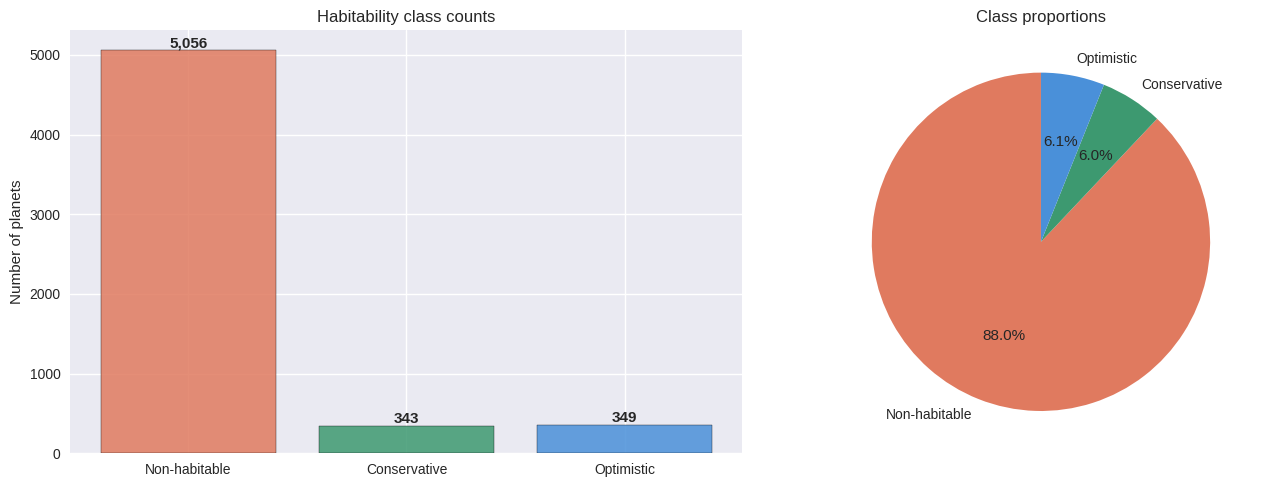

Balanced class weights: {0: 0.38, 1: 5.59, 2: 5.49}


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e07a5f', '#3d9970', '#4a90d9']
labels = [CLASS_NAMES[k] for k in class_counts.index]

bars = ax1.bar(labels, class_counts.values, color=colors, edgecolor='black', alpha=0.85)
for b, v in zip(bars, class_counts.values):
    ax1.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
ax1.set_title('Habitability class counts')
ax1.set_ylabel('Number of planets')

ax2.pie(class_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Class proportions')
plt.tight_layout()
plt.show()

class_weights = {k: len(planets) / (len(class_counts) * v) for k, v in class_counts.items()}
print('Balanced class weights:', {k: round(w, 2) for k, w in class_weights.items()})

### 3.3. Automated EDA with dabl
`dabl` gives a quick type inference and a set of target-aware plots. It is run on the physical columns only, since the coordinate, magnitude and uncertainty columns are not relevant to habitability.

dabl feature types:
continuous                  13
dirty_float                  0
low_card_int_ordinal         0
low_card_int_categorical     0
categorical                  2
date                         0
free_string                  0
useless                      0
Target looks like classification


Linear Discriminant Analysis training set score: 0.382


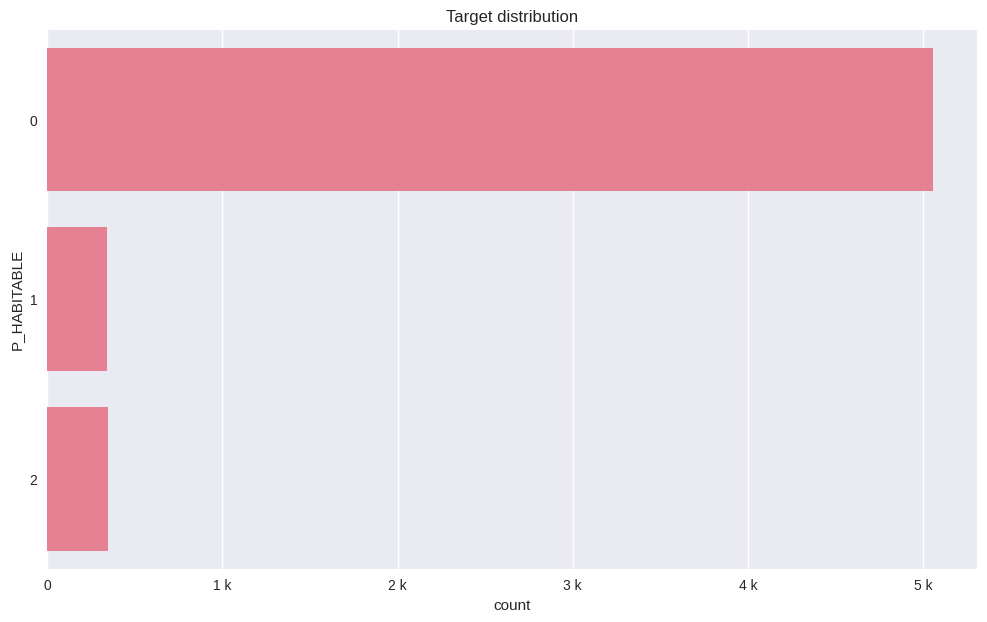

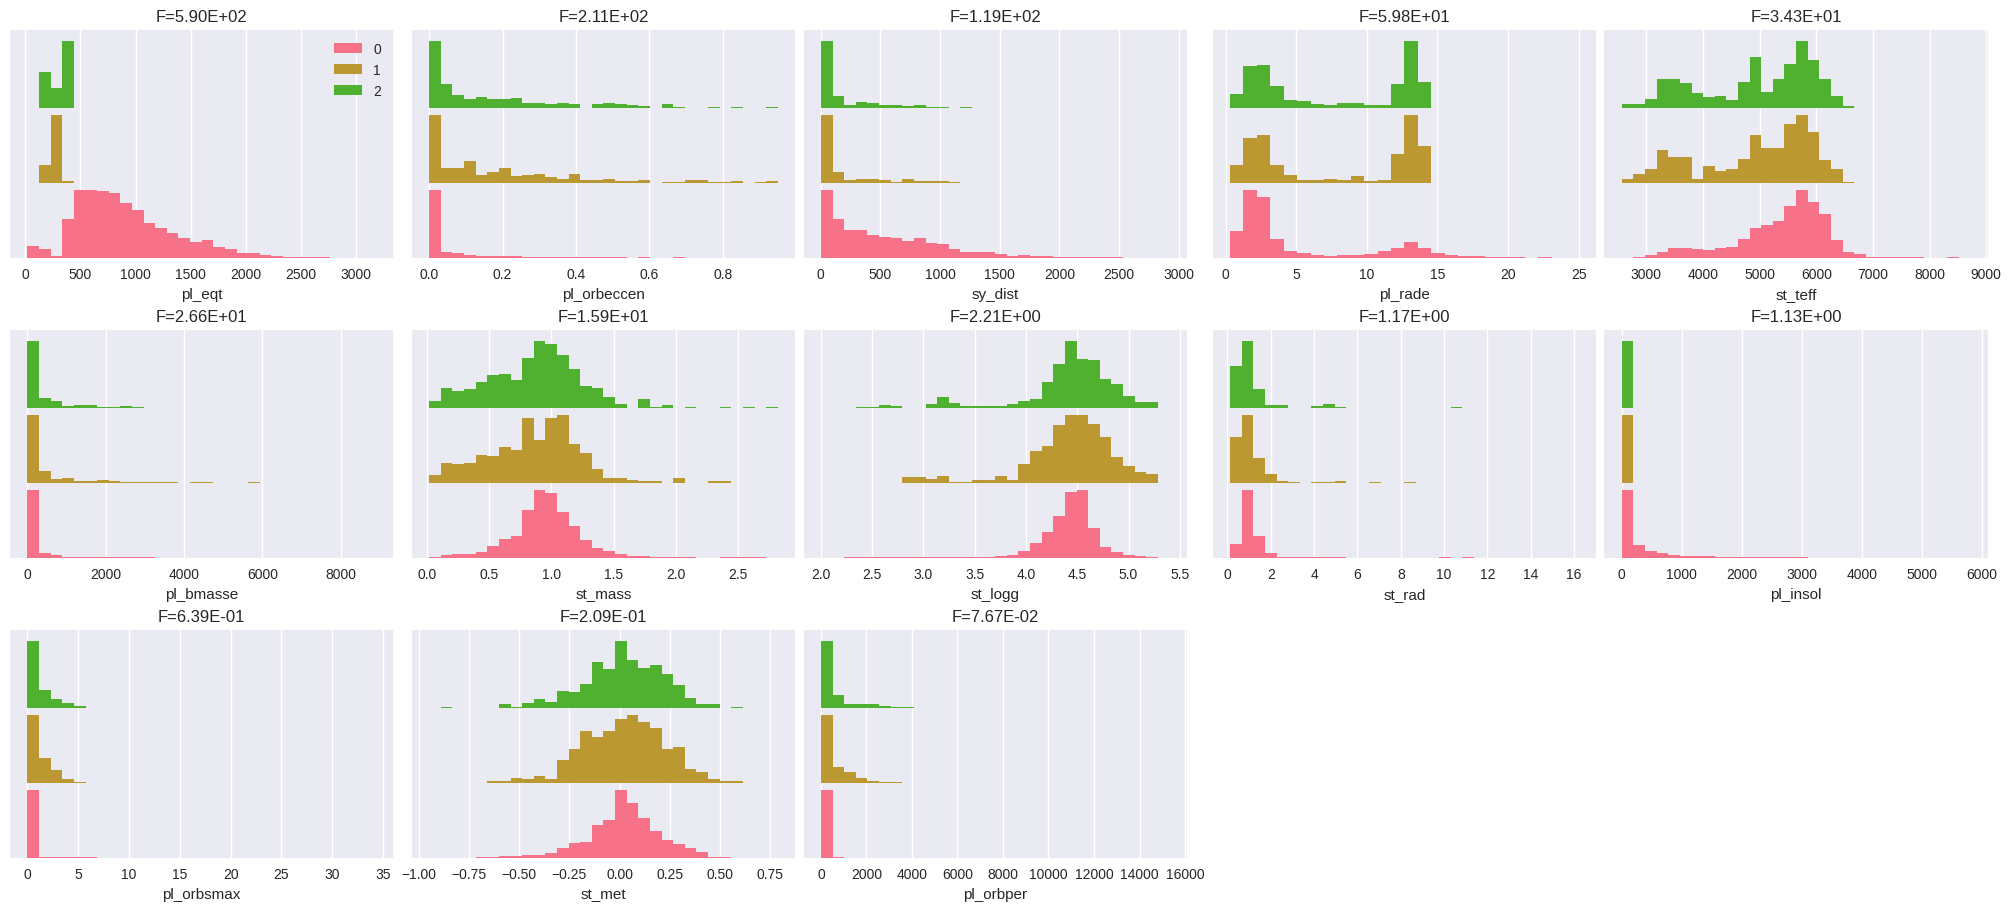

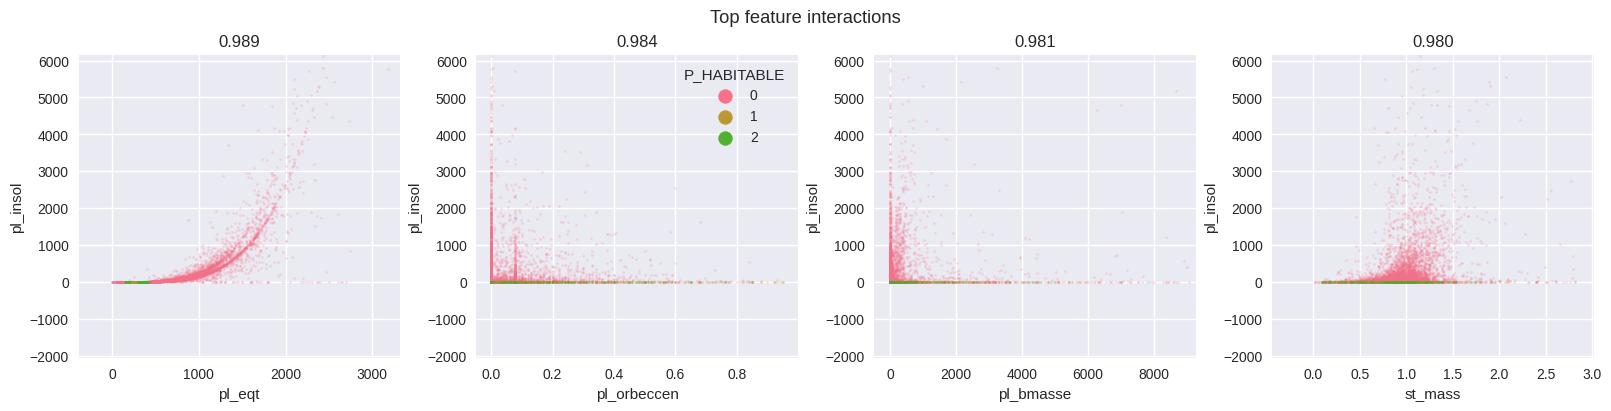

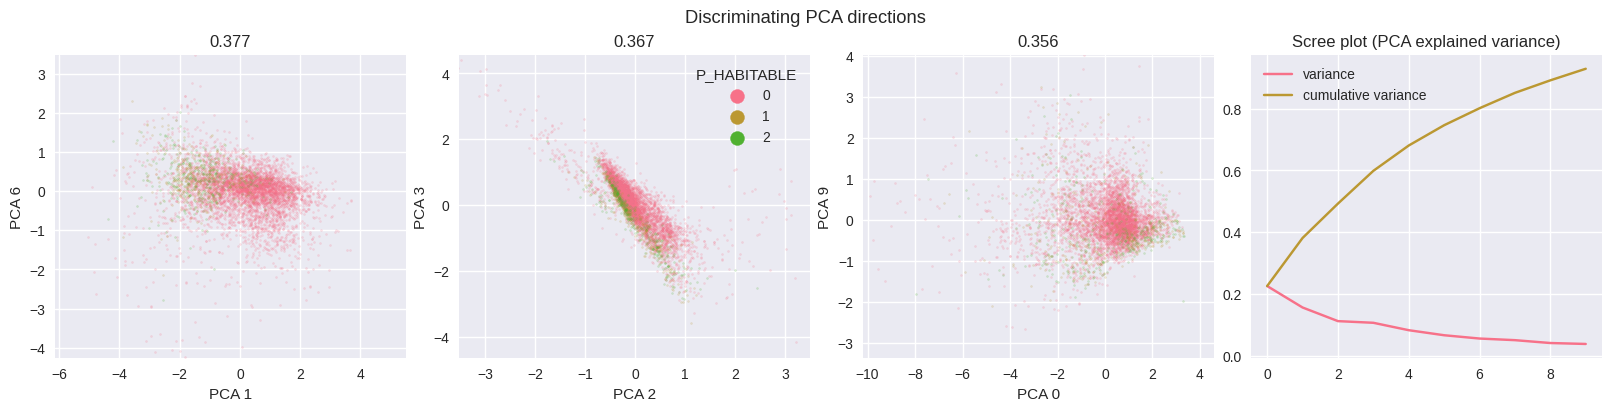

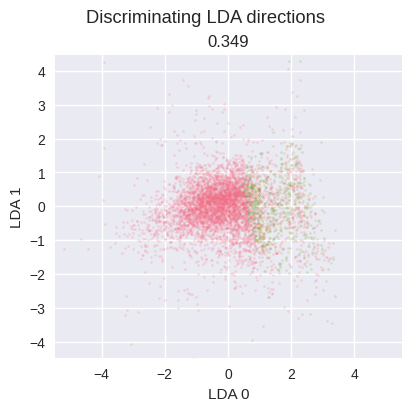

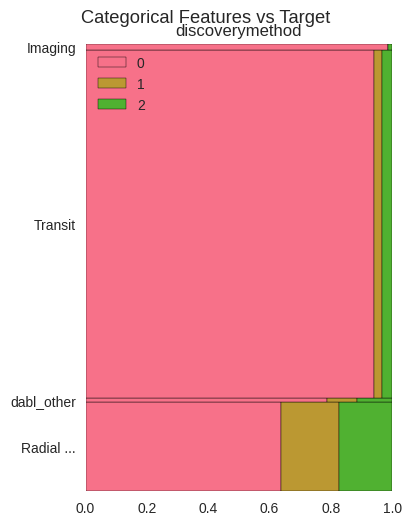

In [7]:
try:
    import dabl
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'dabl'], check=False)
    import dabl

eda_cols = ['pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_orbeccen', 'pl_insol', 'pl_eqt',
            'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_logg', 'sy_dist', 'discoverymethod', 'P_HABITABLE']
eda_df = planets[[c for c in eda_cols if c in planets.columns]].copy()

types = dabl.detect_types(eda_df)
print('dabl feature types:')
print(types.sum().to_string())

dabl.plot(eda_df, target_col='P_HABITABLE')
plt.show()

### 3.4. Habitable Zone View and Physical Parameters by Class

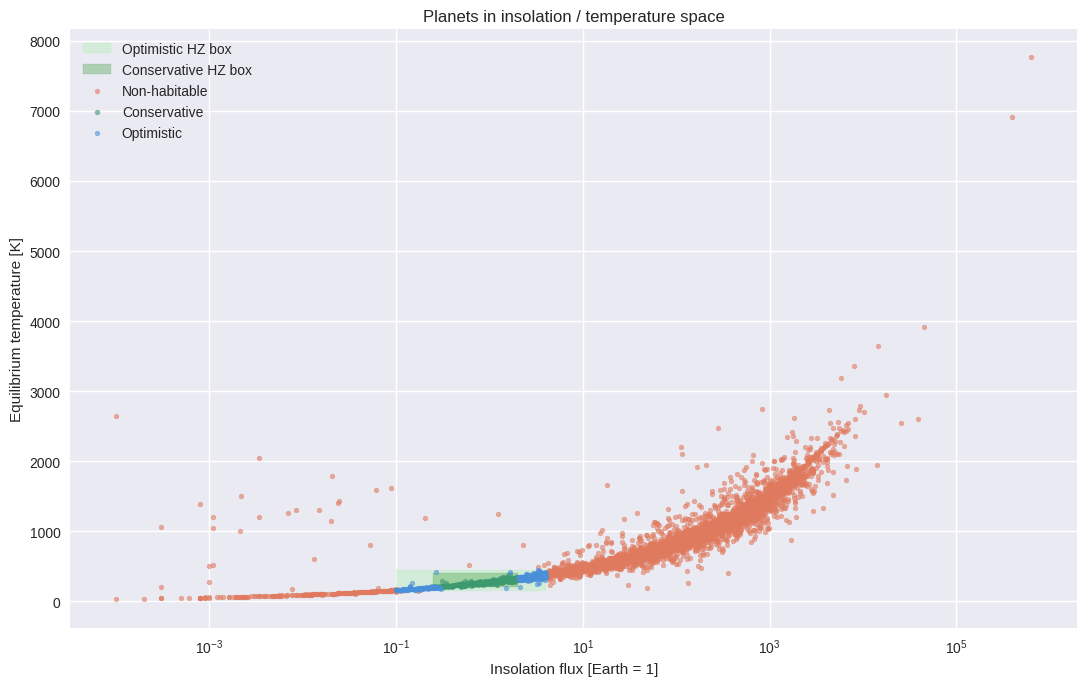

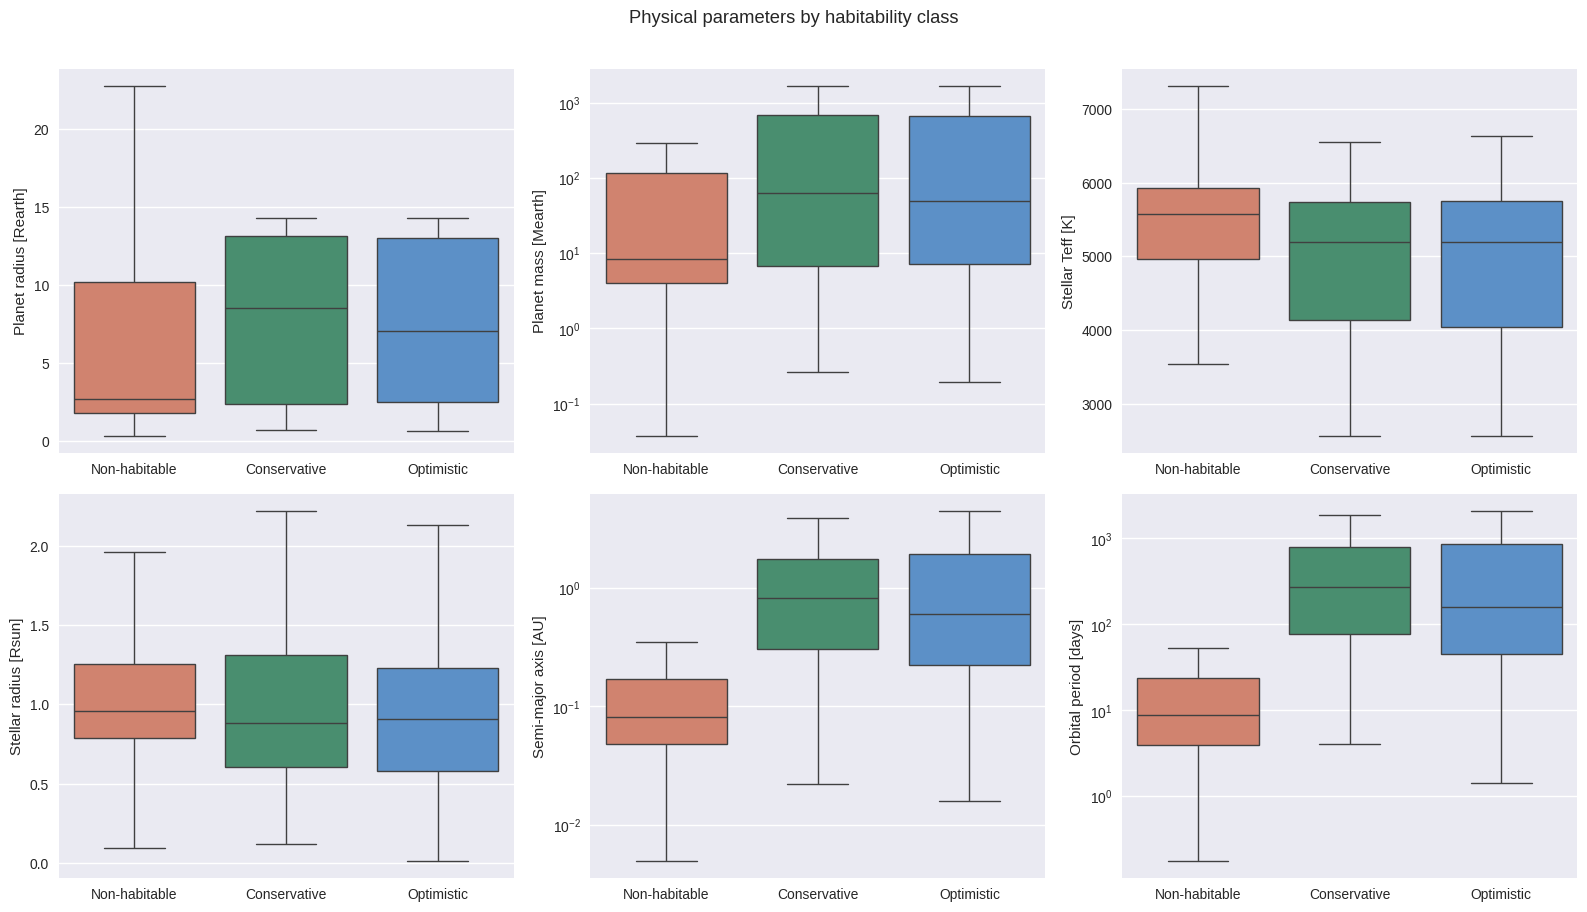

Median values by class:
               pl_rade  pl_bmasse  st_teff  st_rad  pl_orbsmax  pl_orbper
P_HABITABLE                                                              
Non-habitable    2.698      8.400   5576.0    0.96       0.082      8.730
Conservative     8.507     63.566   5198.0    0.88       0.821    273.690
Optimistic       7.060     49.581   5194.0    0.91       0.603    160.018


In [8]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.fill_between([0.1, 4.0], 150, 450, color='lightgreen', alpha=0.25, label='Optimistic HZ box')
ax.fill_between([0.25, 2.0], 200, 400, color='green', alpha=0.25, label='Conservative HZ box')
for k, c in zip([0, 1, 2], colors):
    sub = planets[planets['P_HABITABLE'] == k]
    ax.scatter(sub['pl_insol'], sub['pl_eqt'], s=12, alpha=0.6, color=c, label=CLASS_NAMES[k])
ax.set_xscale('log')
ax.set_xlabel('Insolation flux [Earth = 1]')
ax.set_ylabel('Equilibrium temperature [K]')
ax.set_title('Planets in insolation / temperature space')
ax.legend()
plt.tight_layout()
plt.show()

show = {'pl_rade': 'Planet radius [Rearth]', 'pl_bmasse': 'Planet mass [Mearth]',
        'st_teff': 'Stellar Teff [K]', 'st_rad': 'Stellar radius [Rsun]',
        'pl_orbsmax': 'Semi-major axis [AU]', 'pl_orbper': 'Orbital period [days]'}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, name) in zip(axes.ravel(), show.items()):
    sns.boxplot(data=planets, x='P_HABITABLE', y=col, ax=ax, palette=colors, showfliers=False)
    ax.set_xticklabels([CLASS_NAMES[k] for k in [0, 1, 2]])
    ax.set_xlabel('')
    ax.set_ylabel(name)
    if col in ('pl_bmasse', 'pl_orbsmax', 'pl_orbper'):
        ax.set_yscale('log')
plt.suptitle('Physical parameters by habitability class', y=1.01)
plt.tight_layout()
plt.show()

print('Median values by class:')
print(planets.groupby('P_HABITABLE')[list(show)].median().round(3).rename(index=CLASS_NAMES).to_string())

## 4. Feature Engineering & Preprocessing

### 4.1. Goldilocks Zone Feature Engineering
The label depends on how much energy the planet receives, so the natural predictors are:

- **Stellar luminosity** L = R² (T/5772)⁴ in solar units, computed from `st_rad` and `st_teff` (the archive `st_lum` column is sparse).
- **Semi-major axis**: `pl_orbsmax`, and where that is missing it is recovered from Kepler's third law, a³ = M P².
- **Estimated insolation** L / a² and its log. This is *not* the archive `pl_insol` value; it comes from the star and orbit alone and differs from it whenever the archive used different stellar parameters, an eccentric orbit or a different source.
- **Habitable-zone position**: (a − a_inner) / (a_outer − a_inner) with a_inner = 0.95 √L and a_outer = 1.37 √L, so 0–1 means inside the classic HZ.
- **Planet density** relative to Earth (M / R³) and an interior Earth Similarity Index built from radius and density.
- Heavy-tailed quantities are log-transformed so that the linear/kernel models are not dominated by a few extreme values.

Columns held out as leakage: `pl_insol`, `pl_eqt` and their `err`/`lim` companions. Uncertainty, limit-flag, coordinate and magnitude columns are dropped as they carry no physical information about habitability.

In [9]:
def add_features(df):
    d = df.copy()

    d['stellar_luminosity'] = d['st_rad'] ** 2 * (d['st_teff'] / 5772.0) ** 4

    # fill semi-major axis from Kepler's third law when the archive value is missing
    a_kepler = (d['st_mass'] * (d['pl_orbper'] / 365.25) ** 2) ** (1 / 3)
    d['semi_major_axis'] = d['pl_orbsmax'].fillna(a_kepler)

    d['est_insol'] = d['stellar_luminosity'] / d['semi_major_axis'] ** 2
    d['hz_inner'] = 0.95 * np.sqrt(d['stellar_luminosity'])
    d['hz_outer'] = 1.37 * np.sqrt(d['stellar_luminosity'])
    d['hz_position'] = (d['semi_major_axis'] - d['hz_inner']) / (d['hz_outer'] - d['hz_inner'])

    d['planet_density'] = d['pl_bmasse'] / d['pl_rade'] ** 3          # Earth = 1
    esi_r = 1 - np.abs((d['pl_rade'] - 1) / (d['pl_rade'] + 1))
    esi_d = 1 - np.abs((d['planet_density'] - 1) / (d['planet_density'] + 1))
    d['esi_interior'] = np.sqrt(esi_r.clip(lower=0) * esi_d.clip(lower=0))

    for col in ['pl_orbper', 'semi_major_axis', 'pl_rade', 'pl_bmasse', 'sy_dist',
                'stellar_luminosity', 'est_insol', 'planet_density']:
        d['log_' + col] = np.log10(d[col].where(d[col] > 0))

    return d.replace([np.inf, -np.inf], np.nan)

planets = add_features(planets)
all_planets = add_features(raw)

FEATURES = [
    'log_pl_orbper', 'log_semi_major_axis', 'log_pl_rade', 'log_pl_bmasse', 'pl_orbeccen',
    'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_logg', 'log_sy_dist', 'sy_snum', 'sy_pnum',
    'log_stellar_luminosity', 'log_est_insol', 'hz_position', 'log_planet_density', 'esi_interior',
]
LEAKAGE = [c for c in planets.columns if c.startswith('pl_insol') or c.startswith('pl_eqt')]

print(f'{len(FEATURES)} model features')
print(f'Held-out label-source columns: {LEAKAGE}')
print('\nEngineered feature summary:')
print(planets[['stellar_luminosity', 'semi_major_axis', 'est_insol', 'hz_position',
               'planet_density', 'esi_interior']].describe().round(3).to_string())

18 model features
Held-out label-source columns: ['pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim']

Engineered feature summary:
       stellar_luminosity  semi_major_axis   est_insol  hz_position  planet_density  esi_interior
count            5745.000         5747.000    5744.000     5744.000        5685.000      5685.000
mean                7.030           11.020     511.330      113.712           2.824         0.520
std               100.209          240.323    9517.693     2631.281          62.347         0.265
min                 0.000            0.005       0.000       -2.259           0.005         0.017
25%                 0.353            0.051      10.033       -2.118           0.248         0.280
50%                 0.844            0.092      65.198       -1.967           0.472         0.530
75%                 1.842            0.230     274.817       -1.510           0.847         0.738
max              6264.836  

### 4.2. Correlations Between Features and With the Target

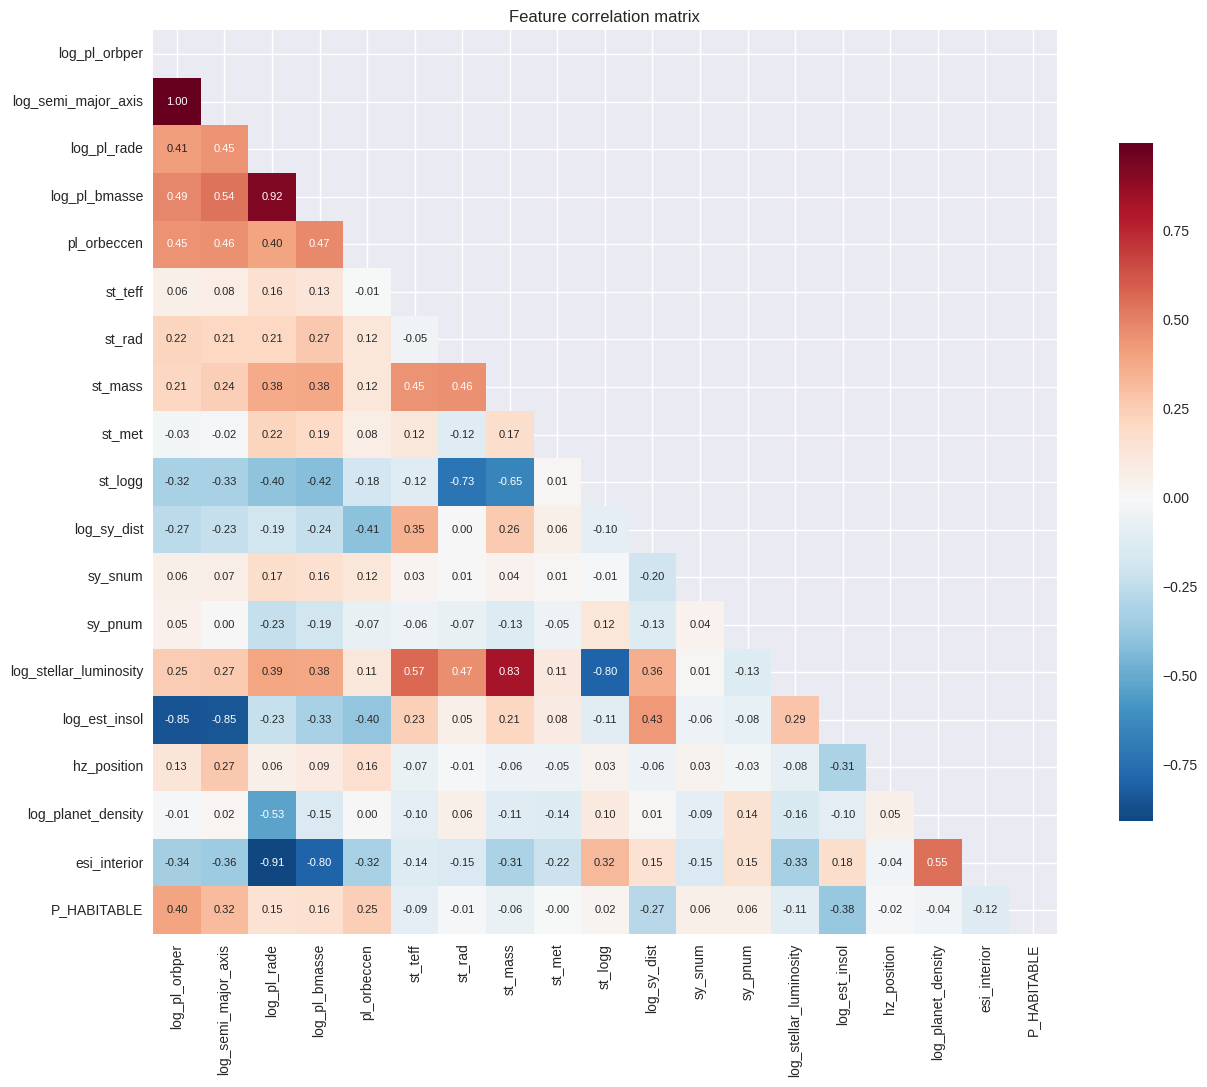

Absolute correlation with P_HABITABLE:
log_pl_orbper             0.399
log_est_insol             0.377
log_semi_major_axis       0.317
log_sy_dist               0.270
pl_orbeccen               0.248
log_pl_bmasse             0.159
log_pl_rade               0.150
esi_interior              0.122
log_stellar_luminosity    0.109
st_teff                   0.094
st_mass                   0.063
sy_pnum                   0.061
sy_snum                   0.059
log_planet_density        0.038
st_logg                   0.024
hz_position               0.015
st_rad                    0.015
st_met                    0.004

Strongly correlated feature pairs (|r| > 0.8):
  log_pl_orbper / log_semi_major_axis: 1.00
  log_pl_rade / log_pl_bmasse: 0.92
  log_pl_rade / esi_interior: -0.91
  log_pl_orbper / log_est_insol: -0.85
  log_semi_major_axis / log_est_insol: -0.85
  st_mass / log_stellar_luminosity: 0.83
  log_pl_bmasse / esi_interior: -0.80


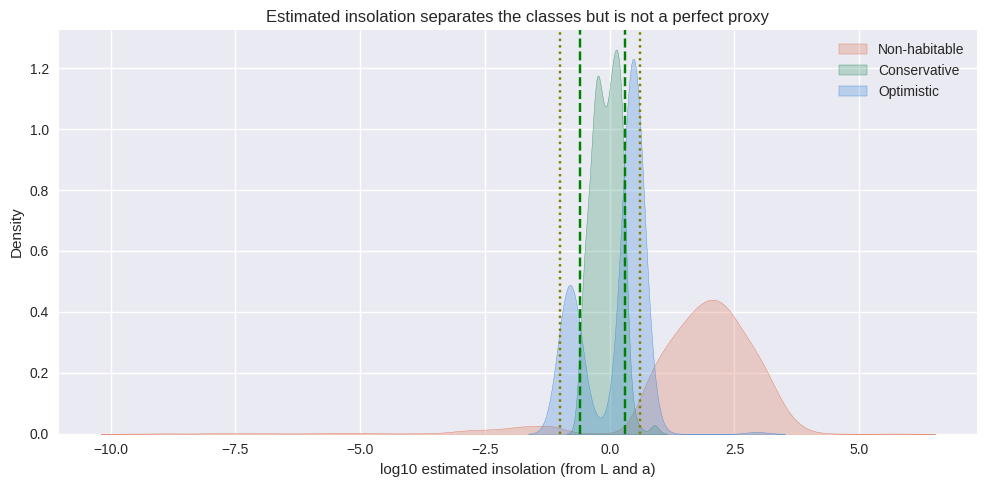

In [10]:
corr = planets[FEATURES + ['P_HABITABLE']].corr()
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            cbar_kws={'shrink': 0.75}, annot_kws={'size': 8})
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

print('Absolute correlation with P_HABITABLE:')
print(corr['P_HABITABLE'].drop('P_HABITABLE').abs().sort_values(ascending=False).round(3).to_string())

pairs = [(corr.columns[i], corr.columns[j], corr.iloc[i, j])
         for i in range(len(FEATURES)) for j in range(i + 1, len(FEATURES)) if abs(corr.iloc[i, j]) > 0.8]
print('\nStrongly correlated feature pairs (|r| > 0.8):')
for a, b, r in sorted(pairs, key=lambda x: -abs(x[2])):
    print(f'  {a} / {b}: {r:.2f}')

fig, ax = plt.subplots(figsize=(10, 5))
for k, c in zip([0, 1, 2], colors):
    sns.kdeplot(planets.loc[planets['P_HABITABLE'] == k, 'log_est_insol'].dropna(), ax=ax, color=c,
                label=CLASS_NAMES[k], fill=True, alpha=0.3)
ax.axvline(np.log10(0.25), ls='--', c='green'); ax.axvline(np.log10(2.0), ls='--', c='green')
ax.axvline(np.log10(0.1), ls=':', c='olive'); ax.axvline(np.log10(4.0), ls=':', c='olive')
ax.set_xlabel('log10 estimated insolation (from L and a)')
ax.set_title('Estimated insolation separates the classes but is not a perfect proxy')
ax.legend()
plt.tight_layout()
plt.show()

### 4.3. Feature Importance Screening
A quick random forest on median-imputed data ranks the features. Nothing is dropped at this stage; the ranking is a sanity check that the physics-based features are doing the work.

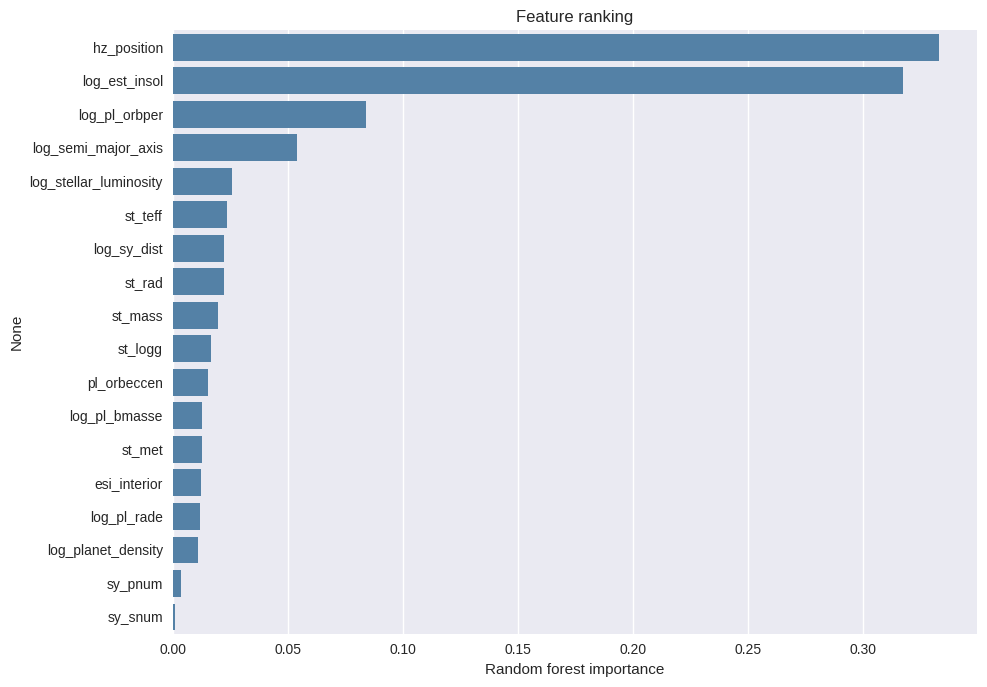

hz_position               0.3329
log_est_insol             0.3175
log_pl_orbper             0.0839
log_semi_major_axis       0.0539
log_stellar_luminosity    0.0258
st_teff                   0.0237
log_sy_dist               0.0225
st_rad                    0.0221
st_mass                   0.0198
st_logg                   0.0166
pl_orbeccen               0.0154
log_pl_bmasse             0.0128
st_met                    0.0125
esi_interior              0.0124
log_pl_rade               0.0119
log_planet_density        0.0112
sy_pnum                   0.0038
sy_snum                   0.0011


In [11]:
X_all = planets[FEATURES]
y_all = planets['P_HABITABLE']

screen = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
])
screen.fit(X_all, y_all)
importance = pd.Series(screen.named_steps['rf'].feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=importance.values, y=importance.index, color='steelblue')
plt.xlabel('Random forest importance')
plt.title('Feature ranking')
plt.tight_layout()
plt.show()

print(importance.round(4).to_string())

### 4.4. Train / Test Split and Class Balancing
A stratified 80/20 split is made once. SMOTE is applied only inside the training folds of each pipeline (never on the test set), so every reported test number is on the original, imbalanced distribution.

Train: 4,598   Test: 1,150
Train class counts: {0: 4045, 1: 274, 2: 279}
Test  class counts: {0: 1011, 1: 69, 2: 70}


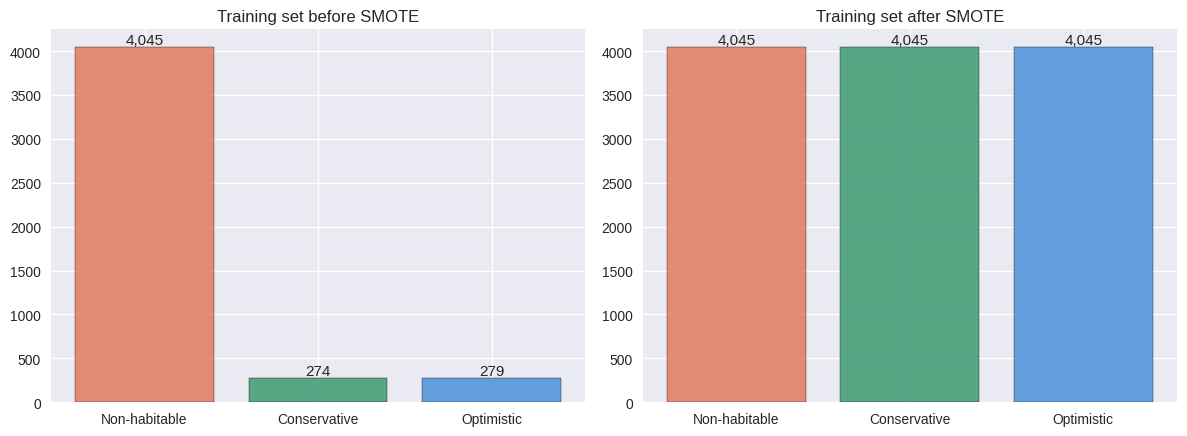

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE)

print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')
print('Train class counts:', y_train.value_counts().sort_index().to_dict())
print('Test  class counts:', y_test.value_counts().sort_index().to_dict())

# illustration only: what SMOTE does to the training distribution
X_demo = SimpleImputer(strategy='median').fit_transform(X_train)
_, y_demo = SMOTE(random_state=RANDOM_STATE).fit_resample(X_demo, y_train)
before = y_train.value_counts().sort_index()
after = pd.Series(y_demo).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, s, t in zip(axes, [before, after], ['Training set before SMOTE', 'Training set after SMOTE']):
    ax.bar([CLASS_NAMES[k] for k in s.index], s.values, color=colors, alpha=0.85, edgecolor='black')
    for i, v in enumerate(s.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom')
    ax.set_title(t)
plt.tight_layout()
plt.show()

## 5. Supervised Learning

### 5.1. Model Comparison with Stratified Cross-Validation
Every candidate is wrapped in the same pipeline: median imputation → scaling → SMOTE → classifier. Macro-F1 is used as the selection metric because accuracy is dominated by the non-habitable class.

Logistic Regression  macro-F1 0.570 ± 0.021   accuracy 0.850 ± 0.017


SVM (RBF)            macro-F1 0.753 ± 0.015   accuracy 0.928 ± 0.004


Random Forest        macro-F1 0.870 ± 0.020   accuracy 0.966 ± 0.005


Gradient Boosting    macro-F1 0.895 ± 0.013   accuracy 0.971 ± 0.004


XGBoost              macro-F1 0.895 ± 0.019   accuracy 0.972 ± 0.006

                     macro_f1_mean  macro_f1_std  weighted_f1_mean  weighted_f1_std  accuracy_mean  accuracy_std  macro_recall_mean  macro_recall_std
Model                                                                                                                                                
XGBoost                      0.895         0.019             0.973            0.005          0.972         0.006              0.901             0.013
Gradient Boosting            0.895         0.013             0.972            0.004          0.971         0.004              0.913             0.014
Random Forest                0.870         0.020             0.968            0.004          0.966         0.005              0.886             0.025
SVM (RBF)                    0.753         0.015             0.933            0.003          0.928         0.004              0.776             0.027
Logistic Regression          0

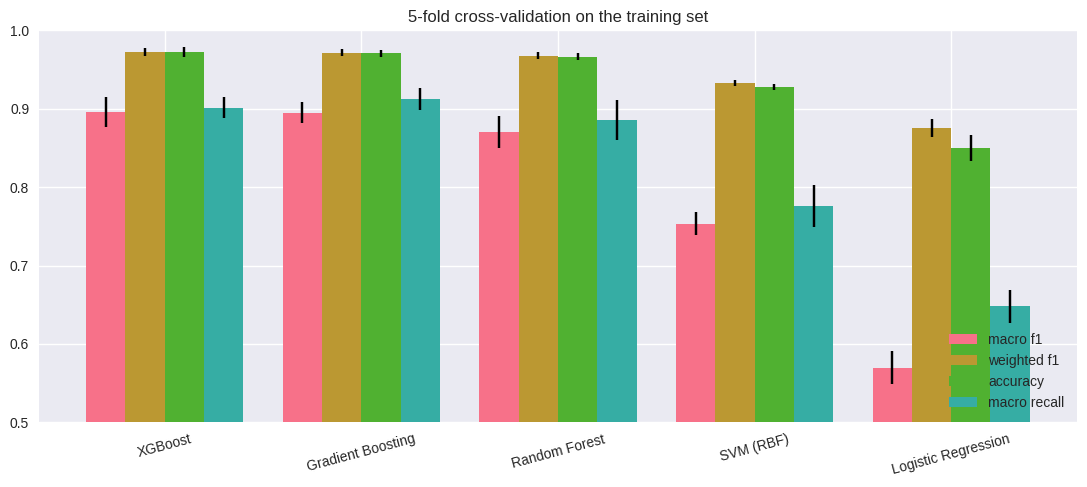

Best model by macro-F1: XGBoost


In [13]:
def make_pipeline(model, scale=True):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps += [('smote', SMOTE(random_state=RANDOM_STATE)), ('model', model)]
    return Pipeline(steps)

models = {
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)),
    'SVM (RBF)':           make_pipeline(SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE)),
    'Random Forest':       make_pipeline(RandomForestClassifier(n_estimators=400, min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1), scale=False),
    'Gradient Boosting':   make_pipeline(GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE), scale=False),
    'XGBoost':             make_pipeline(xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, subsample=0.9,
                                                           colsample_bytree=0.9, objective='multi:softprob',
                                                           eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1), scale=False),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted', 'accuracy': 'accuracy',
           'macro_recall': 'recall_macro'}

cv_rows = []
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)
    row = {'Model': name}
    for m in scoring:
        row[m + '_mean'] = res['test_' + m].mean()
        row[m + '_std'] = res['test_' + m].std()
    cv_rows.append(row)
    print(f'{name:20s} macro-F1 {row["macro_f1_mean"]:.3f} ± {row["macro_f1_std"]:.3f}   '
          f'accuracy {row["accuracy_mean"]:.3f} ± {row["accuracy_std"]:.3f}')

cv_table = pd.DataFrame(cv_rows).set_index('Model').sort_values('macro_f1_mean', ascending=False)
print()
print(cv_table.round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cv_table))
w = 0.2
for i, m in enumerate(['macro_f1', 'weighted_f1', 'accuracy', 'macro_recall']):
    ax.bar(x + i * w, cv_table[m + '_mean'], w, yerr=cv_table[m + '_std'], capsize=3, label=m.replace('_', ' '))
ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(cv_table.index, rotation=15)
ax.set_ylim(0.5, 1.0)
ax.set_title('5-fold cross-validation on the training set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_name = cv_table.index[0]
print('Best model by macro-F1:', best_name)

### 5.2. Hold-out Performance of Every Model
Each pipeline is fitted on the full training set and scored on the untouched test set. A majority-class dummy is included as the floor.

In [14]:
holdout_rows = []
fitted = {}
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
p = dummy.predict(X_test)
holdout_rows.append({'Model': 'Majority baseline', 'accuracy': accuracy_score(y_test, p),
                     'macro_f1': f1_score(y_test, p, average='macro'),
                     'weighted_f1': f1_score(y_test, p, average='weighted')})

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    p = pipe.predict(X_test)
    per_class = f1_score(y_test, p, average=None, labels=[0, 1, 2])
    holdout_rows.append({'Model': name, 'accuracy': accuracy_score(y_test, p),
                         'macro_f1': f1_score(y_test, p, average='macro'),
                         'weighted_f1': f1_score(y_test, p, average='weighted'),
                         'F1 non-hab': per_class[0], 'F1 conservative': per_class[1], 'F1 optimistic': per_class[2]})

holdout = pd.DataFrame(holdout_rows).set_index('Model')
print(holdout.round(3).to_string())

                     accuracy  macro_f1  weighted_f1  F1 non-hab  F1 conservative  F1 optimistic
Model                                                                                           
Majority baseline       0.879     0.312        0.823         NaN              NaN            NaN
Logistic Regression     0.855     0.580        0.879       0.945            0.398          0.396
SVM (RBF)               0.924     0.721        0.929       0.976            0.687          0.500
Random Forest           0.975     0.911        0.976       0.991            0.924          0.818
Gradient Boosting       0.978     0.928        0.979       0.990            0.950          0.846
XGBoost                 0.977     0.916        0.977       0.991            0.941          0.816


### 5.3. Hyperparameter Tuning
Grid search on the best cross-validated pipeline. SMOTE stays inside the pipeline so resampling happens within each fold.

In [15]:
grids = {
    'Random Forest': {'model__n_estimators': [400], 'model__max_depth': [None, 15],
                      'model__min_samples_leaf': [1, 2], 'model__max_features': ['sqrt', 0.5]},
    'XGBoost': {'model__n_estimators': [300], 'model__max_depth': [4, 6, 8],
                'model__learning_rate': [0.05, 0.1], 'model__min_child_weight': [1, 3]},
    'Gradient Boosting': {'model__n_estimators': [150, 300], 'model__max_depth': [2, 3, 4],
                          'model__learning_rate': [0.05, 0.1]},
    'SVM (RBF)': {'model__C': [1, 10, 100], 'model__gamma': ['scale', 0.05, 0.01]},
    'Logistic Regression': {'model__C': [0.1, 1, 10, 100]},
}

grid = GridSearchCV(models[best_name], grids[best_name], cv=skf, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f'\nTuned model: {best_name}')
print('Best parameters:', {k.replace('model__', ''): v for k, v in grid.best_params_.items()})
print(f'Best CV macro-F1: {grid.best_score_:.3f}')
print(f'Untuned CV macro-F1: {cv_table.loc[best_name, "macro_f1_mean"]:.3f}')

final_model = grid.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits



Tuned model: XGBoost
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 300}
Best CV macro-F1: 0.902
Untuned CV macro-F1: 0.895


### 5.4. Final Model Evaluation on the Hold-out Set

Final model: XGBoost
  accuracy         0.977
  macro_f1         0.920
  weighted_f1      0.978
  macro_precision  0.913
  macro_recall     0.929

Classification report:
               precision    recall  f1-score   support

Non-habitable      0.993     0.988     0.991      1011
 Conservative      0.956     0.942     0.949        69
   Optimistic      0.789     0.857     0.822        70

     accuracy                          0.977      1150
    macro avg      0.913     0.929     0.920      1150
 weighted avg      0.978     0.977     0.978      1150



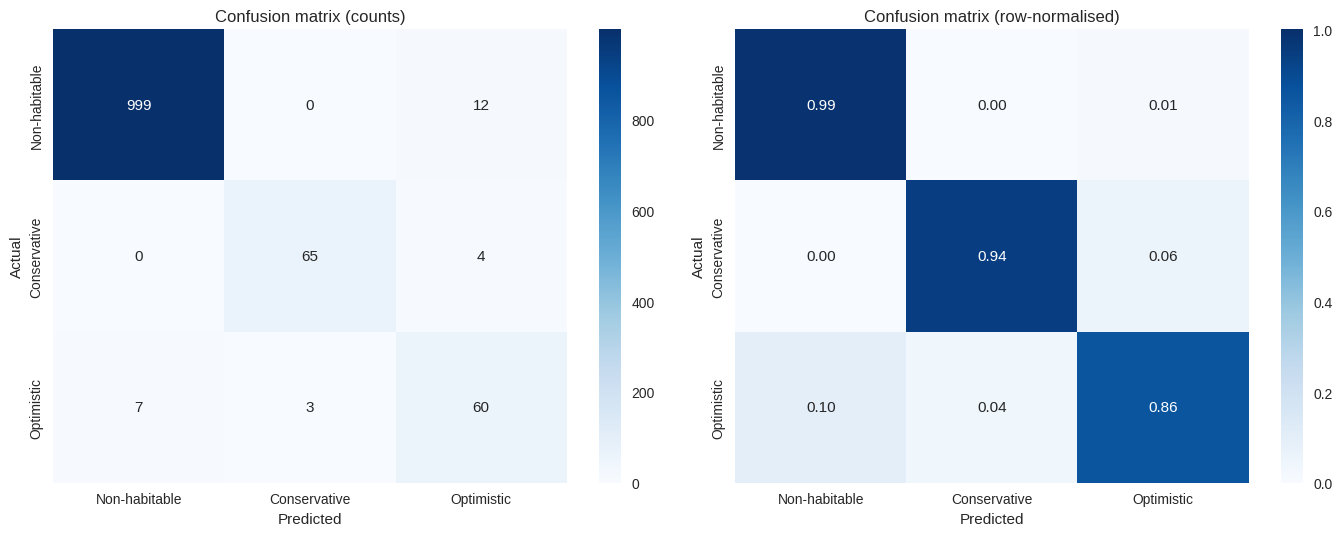

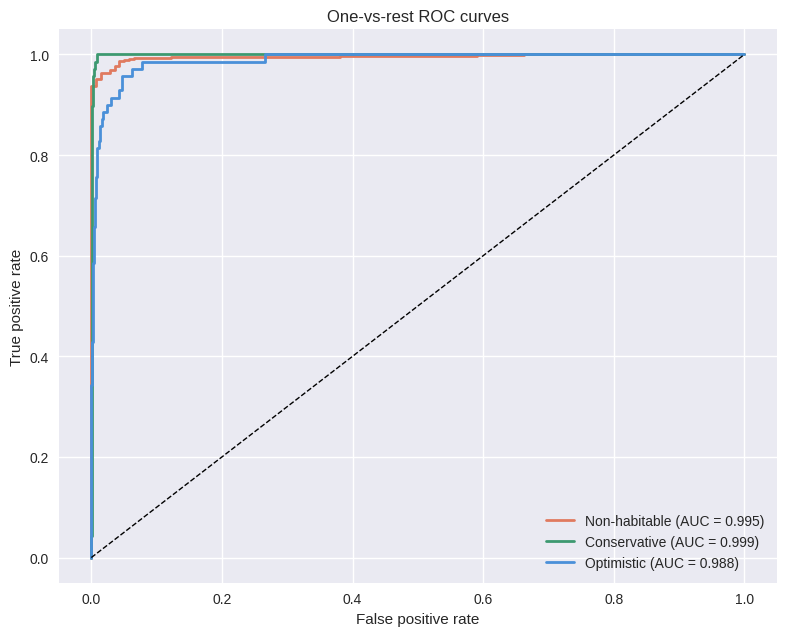

Macro-average ROC AUC: 0.994

Train macro-F1 1.000 vs test 0.920 (gap +0.080)


In [16]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

final_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'macro_f1': f1_score(y_test, y_pred, average='macro'),
    'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
    'macro_precision': precision_score(y_test, y_pred, average='macro'),
    'macro_recall': recall_score(y_test, y_pred, average='macro'),
}
print(f'Final model: {best_name}')
for k, v in final_metrics.items():
    print(f'  {k:16s} {v:.3f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=list(CLASS_NAMES.values()), digits=3))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES.values(), yticklabels=CLASS_NAMES.values())
axes[0].set_title('Confusion matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
cm_norm = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1], vmin=0, vmax=1,
            xticklabels=CLASS_NAMES.values(), yticklabels=CLASS_NAMES.values())
axes[1].set_title('Confusion matrix (row-normalised)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# one-vs-rest ROC curves
y_bin = label_binarize(y_test, classes=[0, 1, 2])
plt.figure(figsize=(8, 6.5))
aucs = {}
for i, c in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    aucs[i] = roc_auc_score(y_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, color=c, lw=2, label=f'{CLASS_NAMES[i]} (AUC = {aucs[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('One-vs-rest ROC curves'); plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
macro_auc = np.mean(list(aucs.values()))
print(f'Macro-average ROC AUC: {macro_auc:.3f}')

train_pred = final_model.predict(X_train)
gap = f1_score(y_train, train_pred, average='macro') - final_metrics['macro_f1']
print(f'\nTrain macro-F1 {f1_score(y_train, train_pred, average="macro"):.3f} vs test {final_metrics["macro_f1"]:.3f} (gap {gap:+.3f})')

### 5.5. Feature Importance and Goldilocks Zone Impact

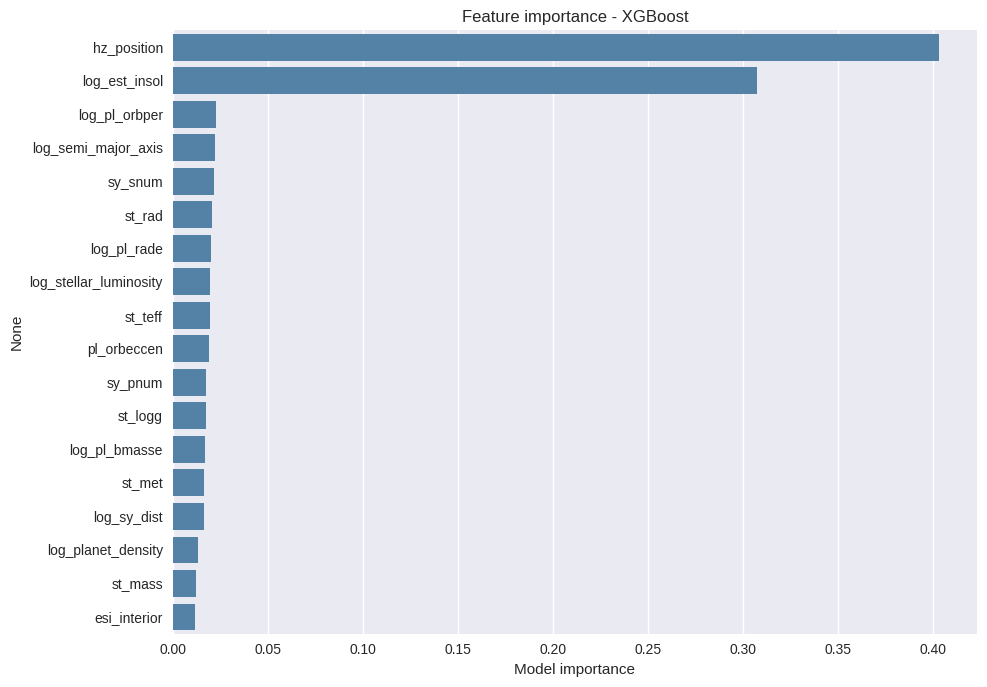

Importance share by feature group:
  Goldilocks / energy budget    77.6%
  Stellar properties             8.7%
  Planet bulk properties         8.1%
  System / context               5.6%


In [17]:
model_step = final_model.named_steps['model']
if hasattr(model_step, 'feature_importances_'):
    imp = pd.Series(model_step.feature_importances_, index=FEATURES)
    imp_label = 'Model importance'
else:
    perm = permutation_importance(final_model, X_test, y_test, scoring='f1_macro', n_repeats=10,
                                  random_state=RANDOM_STATE, n_jobs=-1)
    imp = pd.Series(perm.importances_mean, index=FEATURES)
    imp_label = 'Permutation importance (macro-F1 drop)'
imp = imp.sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=imp.values, y=imp.index, color='steelblue')
plt.xlabel(imp_label)
plt.title(f'Feature importance - {best_name}')
plt.tight_layout()
plt.show()

groups = {
    'Goldilocks / energy budget': ['log_est_insol', 'hz_position', 'log_stellar_luminosity', 'log_semi_major_axis', 'log_pl_orbper'],
    'Stellar properties': ['st_teff', 'st_rad', 'st_mass', 'st_met', 'st_logg'],
    'Planet bulk properties': ['log_pl_rade', 'log_pl_bmasse', 'log_planet_density', 'esi_interior', 'pl_orbeccen'],
    'System / context': ['log_sy_dist', 'sy_snum', 'sy_pnum'],
}
total = imp.clip(lower=0).sum()
print('Importance share by feature group:')
for g, cols in groups.items():
    share = imp[cols].clip(lower=0).sum() / total * 100
    print(f'  {g:28s} {share:5.1f}%')

### 5.6. Model Stability Across Seeds
The tuned configuration is re-evaluated with 10-fold CV and with several SMOTE / model seeds to check that the result is not a lucky split.

In [18]:
best_params = {k.replace('model__', ''): v for k, v in grid.best_params_.items()}

def tuned_pipeline(seed):
    base = models[best_name]
    model = base.named_steps['model'].__class__(**{**base.named_steps['model'].get_params(), **best_params, 'random_state': seed})
    return make_pipeline(model, scale='scaler' in base.named_steps)

cv10 = cross_validate(tuned_pipeline(RANDOM_STATE), X_all, y_all,
                      cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE),
                      scoring='f1_macro', n_jobs=-1)['test_score']
print(f'10-fold macro-F1: {cv10.mean():.3f} ± {cv10.std():.3f}   (min {cv10.min():.3f}, max {cv10.max():.3f})')

seed_scores = []
for seed in [7, 42, 123]:
    s = cross_validate(tuned_pipeline(seed), X_all, y_all,
                       cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                       scoring='f1_macro', n_jobs=-1)['test_score'].mean()
    seed_scores.append(s)
    print(f'  seed {seed:5d}: macro-F1 {s:.3f}')
print(f'Across seeds: {np.mean(seed_scores):.3f} ± {np.std(seed_scores):.3f}')

10-fold macro-F1: 0.908 ± 0.016   (min 0.875, max 0.933)


  seed     7: macro-F1 0.908


  seed    42: macro-F1 0.906


  seed   123: macro-F1 0.904
Across seeds: 0.906 ± 0.002


## 6. Unsupervised Learning

### 6.1. Unlabelled Dataset Preparation
Clustering uses every planet in the archive (including the ones that could not be labelled), the same physical feature set, median imputation and standard scaling. PCA is used for visualisation and to reduce noise before HDBSCAN.

Planets for clustering: 6,336   features: 18
Components for 80% variance: 8, for 95%: 12


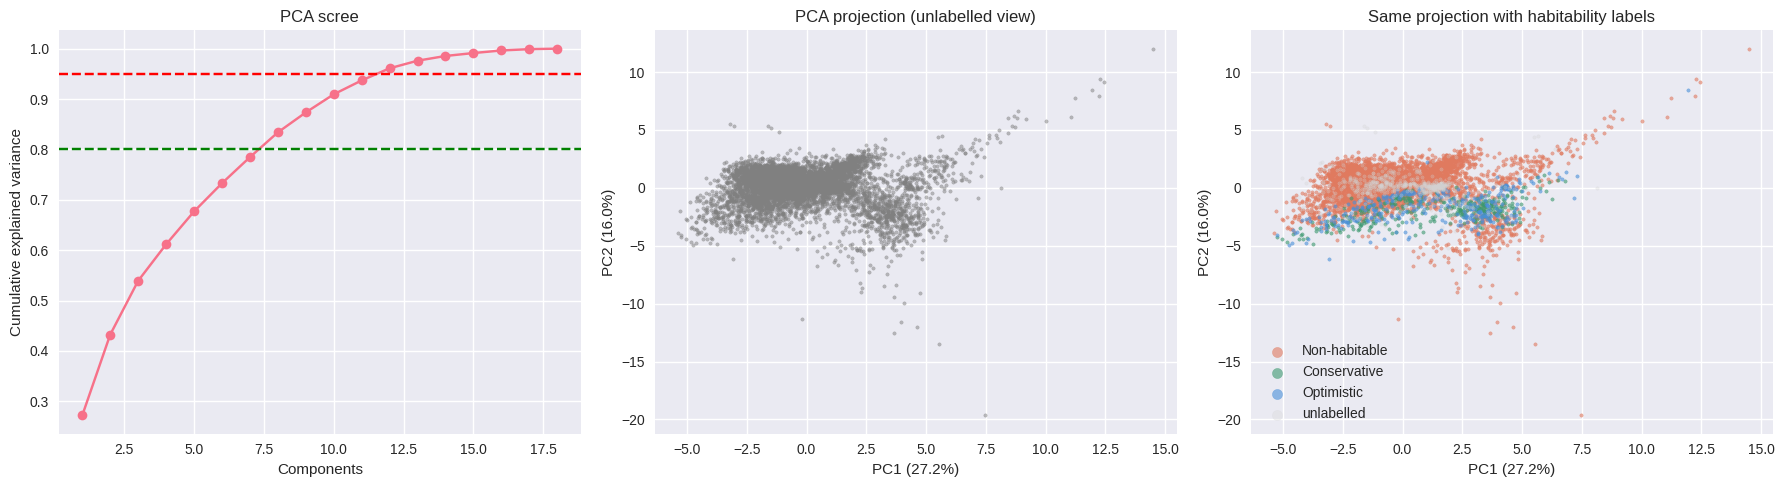

In [19]:
X_unl = all_planets[FEATURES]
print(f'Planets for clustering: {len(X_unl):,}   features: {X_unl.shape[1]}')

unl_prep = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_scaled = unl_prep.fit_transform(X_unl)

pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n80 = int(np.argmax(cum >= 0.80) + 1)
n95 = int(np.argmax(cum >= 0.95) + 1)
print(f'Components for 80% variance: {n80}, for 95%: {n95}')

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_scaled)

labelled_mask = all_planets['P_HABITABLE'].notna().values
y_unl = all_planets['P_HABITABLE'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(range(1, len(cum) + 1), cum, marker='o')
axes[0].axhline(0.8, ls='--', c='g'); axes[0].axhline(0.95, ls='--', c='r')
axes[0].set_xlabel('Components'); axes[0].set_ylabel('Cumulative explained variance')
axes[0].set_title('PCA scree')
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], s=6, alpha=0.5, c='grey')
axes[1].set_title('PCA projection (unlabelled view)')
for k, c in zip([0, 1, 2], colors):
    m = labelled_mask & (y_unl == k)
    axes[2].scatter(X_pca2[m, 0], X_pca2[m, 1], s=6, alpha=0.6, c=c, label=CLASS_NAMES[k])
axes[2].scatter(X_pca2[~labelled_mask, 0], X_pca2[~labelled_mask, 1], s=6, alpha=0.3, c='lightgrey', label='unlabelled')
axes[2].legend(markerscale=3); axes[2].set_title('Same projection with habitability labels')
for ax in axes[1:]:
    ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
plt.tight_layout()
plt.show()

### 6.2. K-means Clustering: Elbow Method and Silhouette

k= 2  inertia=    92550  silhouette=0.266
k= 3  inertia=    81720  silhouette=0.216


k= 4  inertia=    74733  silhouette=0.226
k= 5  inertia=    68481  silhouette=0.205


k= 6  inertia=    63098  silhouette=0.211
k= 7  inertia=    60332  silhouette=0.154


k= 8  inertia=    56322  silhouette=0.197


k= 9  inertia=    53146  silhouette=0.168


k=10  inertia=    50582  silhouette=0.189


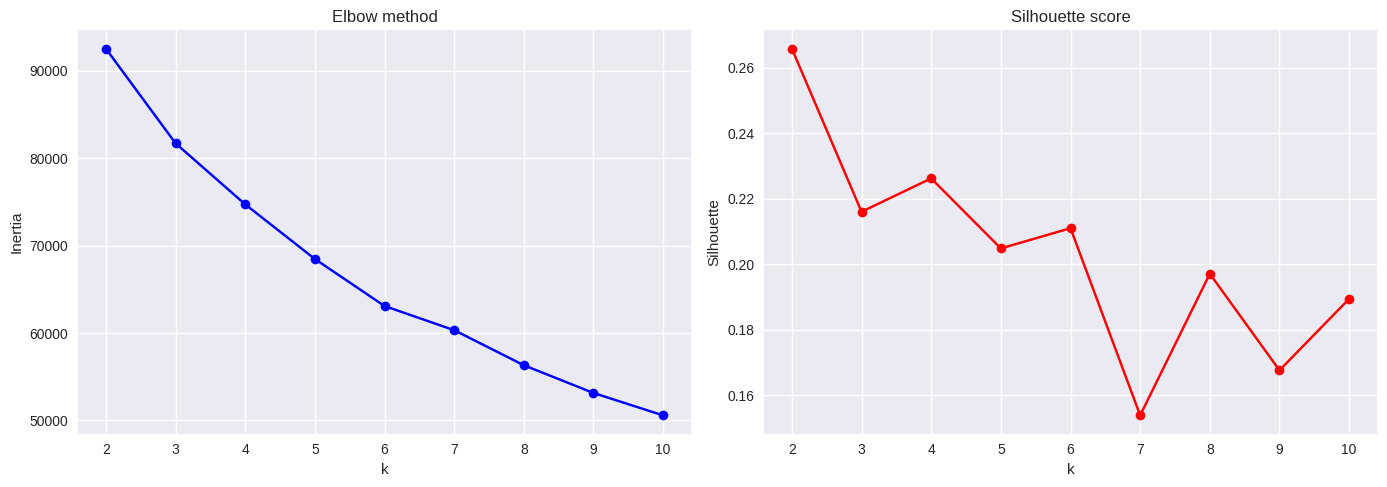

Chosen k (max silhouette): 2


Cluster sizes: {0: 2312, 1: 4024}


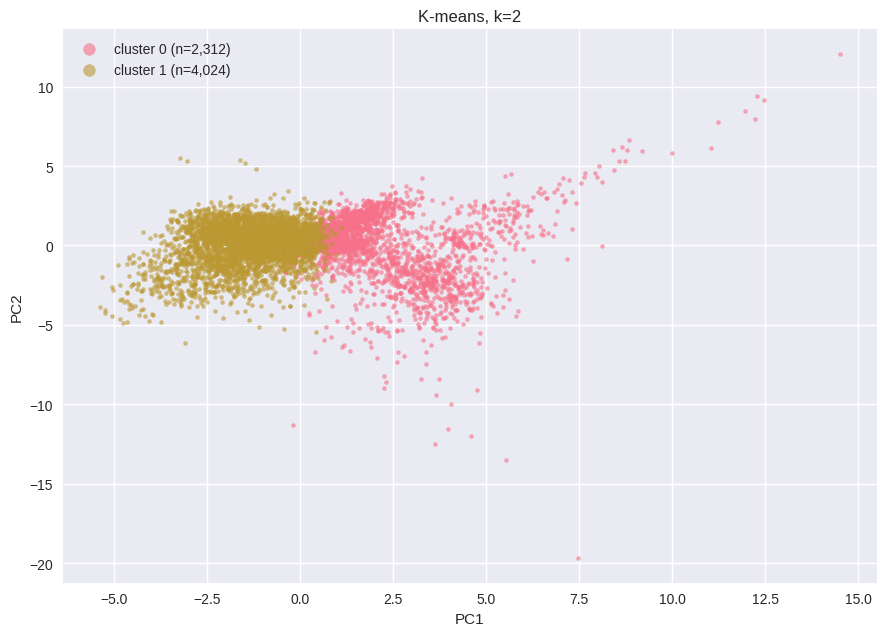

In [20]:
k_range = range(2, 11)
inertias, sils = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_, sample_size=3000, random_state=RANDOM_STATE))
    print(f'k={k:2d}  inertia={km.inertia_:9.0f}  silhouette={sils[-1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'bo-'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow method')
axes[1].plot(list(k_range), sils, 'ro-'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette score')
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sils))]
print(f'Chosen k (max silhouette): {best_k}')

kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
km_labels = kmeans.labels_
km_sizes = pd.Series(km_labels).value_counts().sort_index()
print('Cluster sizes:', km_sizes.to_dict())

plt.figure(figsize=(9, 6.5))
for c in range(best_k):
    m = km_labels == c
    plt.scatter(X_pca2[m, 0], X_pca2[m, 1], s=8, alpha=0.6, label=f'cluster {c} (n={m.sum():,})')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title(f'K-means, k={best_k}'); plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

### 6.3. HDBSCAN Clustering
HDBSCAN is density based, needs no k and marks sparse points as noise. It is run on the first PCA components that carry 80% of the variance, and `min_cluster_size` is chosen by silhouette on the clustered points.

min_cluster_size= 15  clusters= 6  noise= 36.9%  silhouette=0.156


min_cluster_size= 30  clusters= 4  noise= 35.1%  silhouette=0.333


min_cluster_size= 50  clusters= 3  noise= 20.8%  silhouette=0.257


min_cluster_size=100  clusters= 2  noise= 10.7%  silhouette=0.203



Selected min_cluster_size=30: 4 clusters, 2,223 noise points
Cluster sizes: {-1: 2223, 0: 249, 1: 60, 2: 31, 3: 3773}


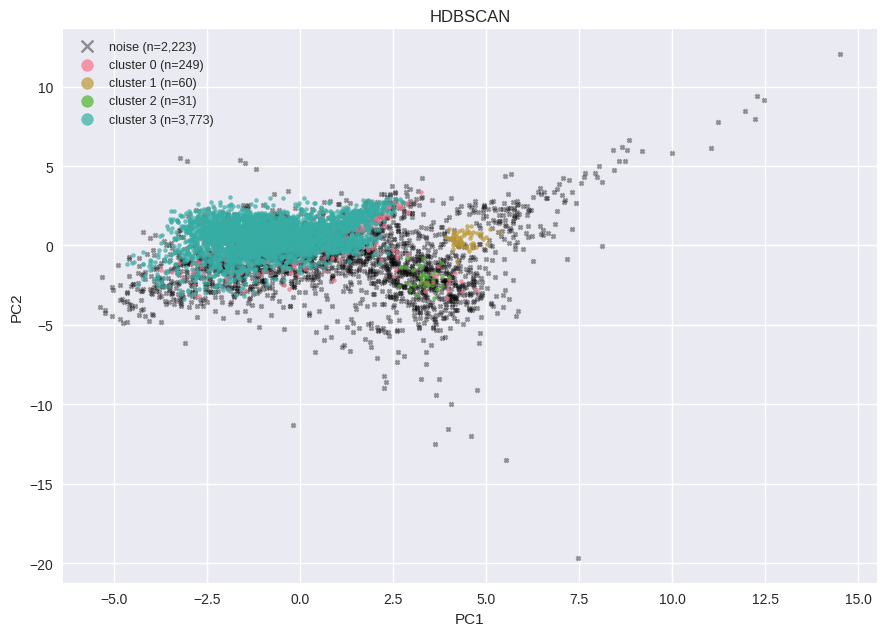

In [21]:
X_pca_red = PCA(n_components=n80, random_state=RANDOM_STATE).fit_transform(X_scaled)

hdb_results = []
for mcs in [15, 30, 50, 100]:
    hdb = HDBSCAN(min_cluster_size=mcs, min_samples=10).fit(X_pca_red)
    lab = hdb.labels_
    n_cl = len(set(lab)) - (1 if -1 in lab else 0)
    noise = (lab == -1).mean()
    core = lab != -1
    sil = silhouette_score(X_pca_red[core], lab[core], sample_size=3000, random_state=RANDOM_STATE) if n_cl > 1 else np.nan
    hdb_results.append({'min_cluster_size': mcs, 'clusters': n_cl, 'noise_%': noise * 100, 'silhouette': sil})
    print(f'min_cluster_size={mcs:3d}  clusters={n_cl:2d}  noise={noise*100:5.1f}%  silhouette={sil:.3f}')

hdb_df = pd.DataFrame(hdb_results)
best_mcs = int(hdb_df.dropna().sort_values('silhouette', ascending=False).iloc[0]['min_cluster_size'])
hdbscan_model = HDBSCAN(min_cluster_size=best_mcs, min_samples=10).fit(X_pca_red)
hdb_labels = hdbscan_model.labels_
n_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = int((hdb_labels == -1).sum())
print(f'\nSelected min_cluster_size={best_mcs}: {n_hdb} clusters, {n_noise:,} noise points')
print('Cluster sizes:', pd.Series(hdb_labels).value_counts().sort_index().to_dict())

plt.figure(figsize=(9, 6.5))
m = hdb_labels == -1
plt.scatter(X_pca2[m, 0], X_pca2[m, 1], s=8, c='black', marker='x', alpha=0.4, label=f'noise (n={m.sum():,})')
for c in sorted(set(hdb_labels) - {-1}):
    m = hdb_labels == c
    plt.scatter(X_pca2[m, 0], X_pca2[m, 1], s=8, alpha=0.7, label=f'cluster {c} (n={m.sum():,})')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('HDBSCAN'); plt.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

### 6.4. Clustering Algorithm Comparison

           clusters  noise_points  silhouette  calinski_harabasz  davies_bouldin    ARI    NMI  homogeneity  completeness
algorithm                                                                                                                
K-means           2             0       0.266           1471.287           1.792  0.066  0.027        0.034         0.023
HDBSCAN           4          2223       0.321            250.448           1.255  0.186  0.068        0.084         0.057

Higher silhouette: HDBSCAN

Median physical parameters per HDBSCAN cluster:
         pl_orbper  semi_major_axis  pl_rade  pl_bmasse  st_teff  stellar_luminosity  est_insol  sy_dist
cluster                                                                                                 
-1           30.60             0.20     7.31      67.78  5303.00                0.88      12.85    94.91
 0            4.67             0.06    11.29      88.99  5625.00                0.87     221.03   194.46
 1          630

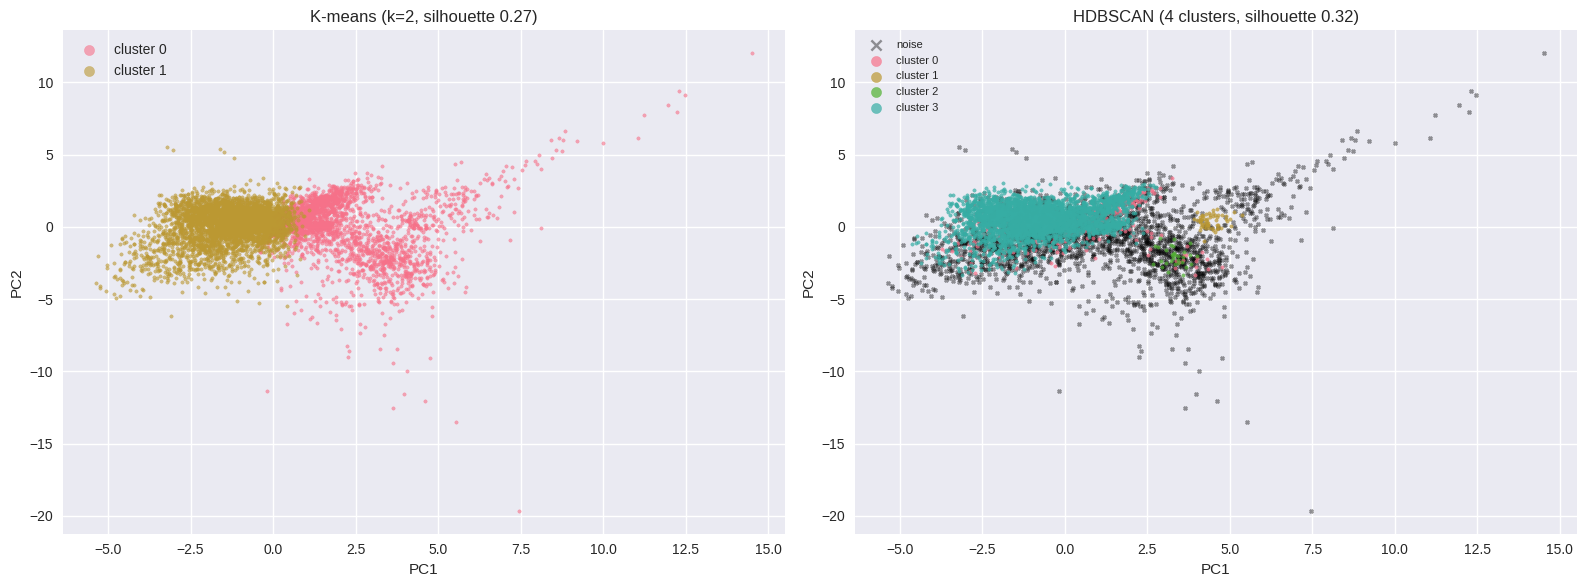

In [22]:
def internal_metrics(X, labels):
    core = labels != -1
    if len(set(labels[core])) < 2:
        return dict(silhouette=np.nan, calinski_harabasz=np.nan, davies_bouldin=np.nan)
    return dict(silhouette=silhouette_score(X[core], labels[core], sample_size=3000, random_state=RANDOM_STATE),
                calinski_harabasz=calinski_harabasz_score(X[core], labels[core]),
                davies_bouldin=davies_bouldin_score(X[core], labels[core]))

def external_metrics(labels):
    m = labelled_mask & (labels != -1)
    yt = y_unl[m].astype(int)
    return dict(ARI=adjusted_rand_score(yt, labels[m]), NMI=normalized_mutual_info_score(yt, labels[m]),
                homogeneity=homogeneity_score(yt, labels[m]), completeness=completeness_score(yt, labels[m]))

rows = []
for name, lab in [('K-means', km_labels), ('HDBSCAN', hdb_labels)]:
    r = {'algorithm': name, 'clusters': len(set(lab) - {-1}), 'noise_points': int((lab == -1).sum())}
    r.update(internal_metrics(X_scaled, lab))
    r.update(external_metrics(lab))
    rows.append(r)
cluster_compare = pd.DataFrame(rows).set_index('algorithm')
print(cluster_compare.round(3).to_string())

best_clustering = cluster_compare['silhouette'].idxmax()
best_labels = km_labels if best_clustering == 'K-means' else hdb_labels
print(f'\nHigher silhouette: {best_clustering}')

# what the clusters look like physically
profile_cols = ['pl_orbper', 'semi_major_axis', 'pl_rade', 'pl_bmasse', 'st_teff', 'stellar_luminosity', 'est_insol', 'sy_dist']
prof = all_planets[profile_cols].copy()
prof['cluster'] = best_labels
print(f'\nMedian physical parameters per {best_clustering} cluster:')
print(prof.groupby('cluster').median().round(2).to_string())

ct = pd.crosstab(pd.Series(best_labels[labelled_mask], name='cluster'),
                 pd.Series(y_unl[labelled_mask].astype(int), name='class').map(CLASS_NAMES))
print(f'\n{best_clustering} cluster vs habitability class (labelled planets only):')
print(ct.to_string())
print('\nRow-normalised:')
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for c in sorted(set(km_labels)):
    m = km_labels == c
    axes[0].scatter(X_pca2[m, 0], X_pca2[m, 1], s=6, alpha=0.6, label=f'cluster {c}')
axes[0].set_title(f'K-means (k={best_k}, silhouette {cluster_compare.loc["K-means","silhouette"]:.2f})'); axes[0].legend(markerscale=3)
m = hdb_labels == -1
axes[1].scatter(X_pca2[m, 0], X_pca2[m, 1], s=6, c='black', marker='x', alpha=0.4, label='noise')
for c in sorted(set(hdb_labels) - {-1}):
    m = hdb_labels == c
    axes[1].scatter(X_pca2[m, 0], X_pca2[m, 1], s=6, alpha=0.7, label=f'cluster {c}')
axes[1].set_title(f'HDBSCAN ({n_hdb} clusters, silhouette {cluster_compare.loc["HDBSCAN","silhouette"]:.2f})'); axes[1].legend(markerscale=3, fontsize=8)
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

## 7. Results Analysis

### 7.1. Silhouette Profile of the Selected Clustering

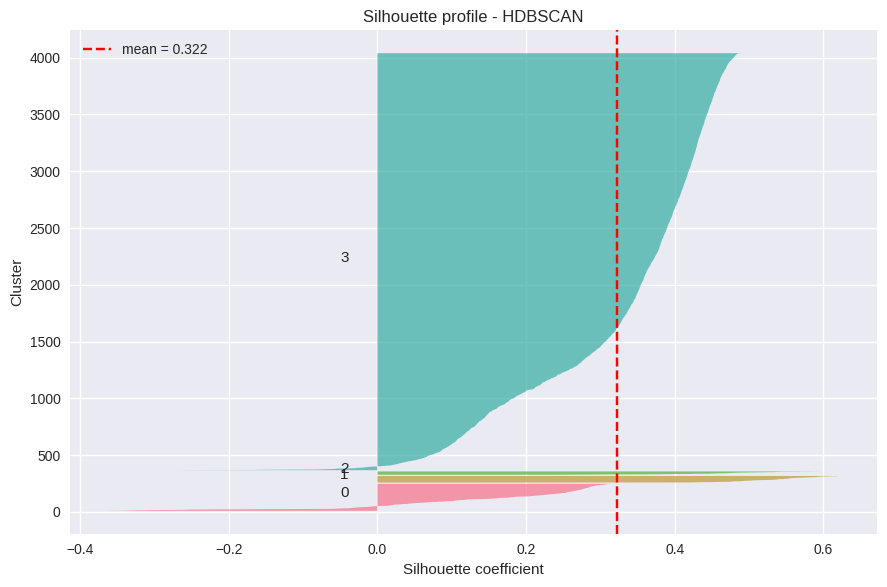

In [23]:
core = best_labels != -1
sample_idx = np.random.RandomState(RANDOM_STATE).choice(np.where(core)[0], size=min(4000, core.sum()), replace=False)
sil_vals = silhouette_samples(X_scaled[sample_idx], best_labels[sample_idx])

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
for c in sorted(set(best_labels[sample_idx])):
    v = np.sort(sil_vals[best_labels[sample_idx] == c])
    ax.fill_betweenx(np.arange(y_lower, y_lower + len(v)), 0, v, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(v), str(c))
    y_lower += len(v) + 10
ax.axvline(sil_vals.mean(), color='red', ls='--', label=f'mean = {sil_vals.mean():.3f}')
ax.set_xlabel('Silhouette coefficient'); ax.set_ylabel('Cluster'); ax.set_title(f'Silhouette profile - {best_clustering}')
ax.legend()
plt.tight_layout()
plt.show()

### 7.2. Supervised vs Unsupervised Comparison
The classifier is trained to reproduce a specific physical definition (the HZ box), while clustering groups planets by their overall parameter profile without any notion of habitability. Comparing the two shows how much of the habitability signal is visible in the natural structure of the data.

Normalised importance vs cluster separation:
                        classifier_importance  cluster_separation
hz_position                             0.403               0.000
log_est_insol                           0.307               0.077
log_pl_orbper                           0.023               0.150
log_semi_major_axis                     0.022               0.092
sy_snum                                 0.022               0.185
st_rad                                  0.021               0.022
log_pl_rade                             0.020               0.052
log_stellar_luminosity                  0.020               0.052
st_teff                                 0.019               0.004
pl_orbeccen                             0.019               0.019
sy_pnum                                 0.018               0.001
st_logg                                 0.018               0.165
log_pl_bmasse                           0.017               0.062
st_met                         

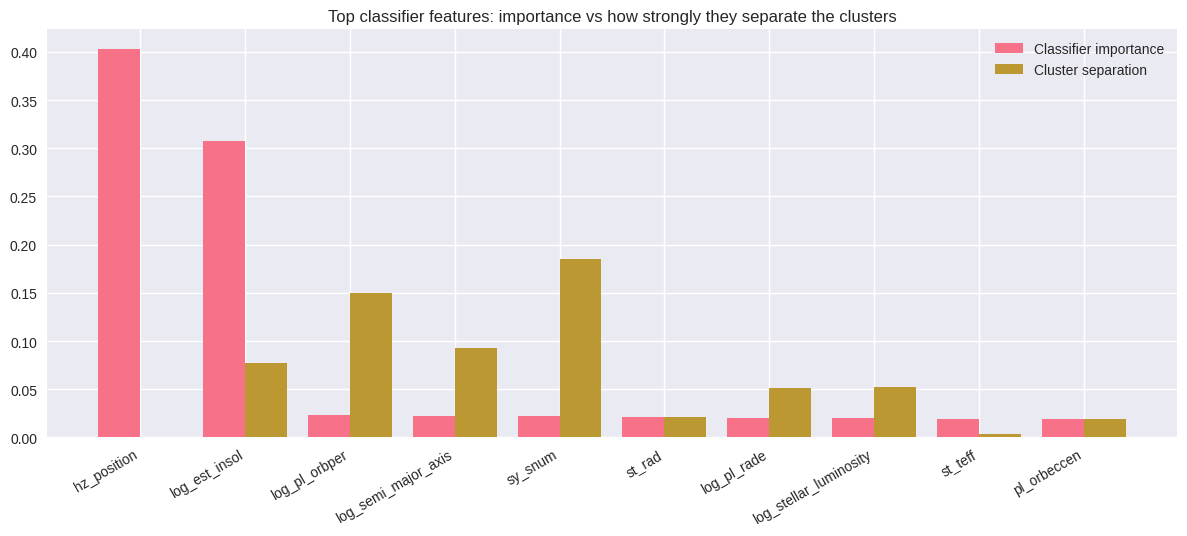


Summary
  Supervised (XGBoost): test macro-F1 0.920, accuracy 0.977, macro AUC 0.994
  Per-class F1: Non-habitable 0.991, Conservative 0.949, Optimistic 0.822
  Unsupervised (HDBSCAN): silhouette 0.321, ARI vs labels 0.186, NMI 0.068
  The clusters follow planet type and detection regime rather than habitability; the habitable planets are a thin slice inside a bigger population.


In [24]:
# how well does each feature separate the clusters vs how much the classifier relies on it
sep = {}
Xdf = pd.DataFrame(X_scaled, columns=FEATURES)
for f in FEATURES:
    means = Xdf.loc[core, f].groupby(best_labels[core]).mean()
    sep[f] = means.var() / Xdf[f].var()
sep = pd.Series(sep)

compare = pd.DataFrame({'classifier_importance': imp / imp.clip(lower=0).sum(),
                        'cluster_separation': sep / sep.sum()}).sort_values('classifier_importance', ascending=False)
print('Normalised importance vs cluster separation:')
print(compare.round(3).to_string())
print(f'\nSpearman correlation between the two rankings: {compare.corr(method="spearman").iloc[0, 1]:.3f}')

top = compare.head(10)
fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(top)); w = 0.4
ax.bar(x - w/2, top['classifier_importance'], w, label='Classifier importance')
ax.bar(x + w/2, top['cluster_separation'], w, label='Cluster separation')
ax.set_xticks(x); ax.set_xticklabels(top.index, rotation=30, ha='right')
ax.set_title('Top classifier features: importance vs how strongly they separate the clusters')
ax.legend()
plt.tight_layout()
plt.show()

print('\nSummary')
print(f'  Supervised ({best_name}): test macro-F1 {final_metrics["macro_f1"]:.3f}, accuracy {final_metrics["accuracy"]:.3f}, macro AUC {macro_auc:.3f}')
print(f'  Per-class F1: ' + ', '.join(f'{CLASS_NAMES[i]} {f:.3f}' for i, f in enumerate(f1_score(y_test, y_pred, average=None))))
print(f'  Unsupervised ({best_clustering}): silhouette {cluster_compare.loc[best_clustering, "silhouette"]:.3f}, '
      f'ARI vs labels {cluster_compare.loc[best_clustering, "ARI"]:.3f}, NMI {cluster_compare.loc[best_clustering, "NMI"]:.3f}')
if cluster_compare.loc[best_clustering, 'ARI'] < 0.2:
    print('  The clusters follow planet type and detection regime rather than habitability; '
          'the habitable planets are a thin slice inside a bigger population.')
else:
    print('  The clusters partly line up with the habitability classes.')

### 7.3. Predicting Individual Planets
A few named planets from the test set plus a hand-built Earth analogue, to see the model behave on concrete cases.

In [25]:
def predict_planets(df):
    Xp = df.reindex(columns=FEATURES)
    proba = final_model.predict_proba(Xp)
    out = pd.DataFrame(proba, columns=[CLASS_NAMES[c] for c in final_model.classes_], index=df.index)
    out.insert(0, 'predicted', [CLASS_NAMES[c] for c in final_model.classes_[proba.argmax(axis=1)]])
    return out.round(3)

test_names = planets.loc[X_test.index, 'pl_name']
wanted = ['TRAPPIST-1 d', 'TRAPPIST-1 e', 'TRAPPIST-1 f', 'TRAPPIST-1 g', 'Kepler-442 b', 'Kepler-452 b', 'Kepler-62 f',
          'Kepler-1649 c', 'Kepler-186 f', 'Kepler-22 b', 'Kepler-438 b', 'Kepler-1229 b', 'Proxima Cen b', 'Ross 128 b',
          'LHS 1140 b', 'K2-18 b', 'GJ 667 C c', 'GJ 273 b', 'Wolf 1061 c', "Teegarden's Star b", 'TOI-700 d', 'TOI-715 b',
          'HD 40307 g', 'HD 209458 b', 'HD 189733 b', 'WASP-12 b', '51 Peg b', '55 Cnc e', 'GJ 1214 b', 'Kepler-10 b']
sample = planets.loc[X_test.index][test_names.isin(wanted)].head(12)
if len(sample) < 4:
    extra = planets.loc[X_test.index]
    sample = pd.concat([sample, extra[extra['P_HABITABLE'] > 0].head(3), extra[extra['P_HABITABLE'] == 0].head(3)]).drop_duplicates('pl_name')

res = predict_planets(sample)
res.insert(0, 'actual', sample['P_HABITABLE'].map(CLASS_NAMES))
res.insert(0, 'planet', sample['pl_name'])
print(res.to_string(index=False))

earth = pd.DataFrame([{'pl_orbper': 365.25, 'pl_orbsmax': 1.0, 'pl_rade': 1.0, 'pl_bmasse': 1.0, 'pl_orbeccen': 0.017,
                       'st_teff': 5772, 'st_rad': 1.0, 'st_mass': 1.0, 'st_met': 0.0, 'st_logg': 4.44,
                       'sy_dist': 10.0, 'sy_snum': 1, 'sy_pnum': 8}])
earth = add_features(earth)
print('\nEarth around a Sun-like star at 1 AU:')
print(predict_planets(earth).to_string(index=False))

hot = earth.copy(); hot['pl_orbper'] = 3.5; hot['pl_orbsmax'] = 0.045; hot['pl_rade'] = 13; hot['pl_bmasse'] = 300
hot = add_features(hot[earth.columns.intersection(hot.columns)])
print('\nHot Jupiter at 0.045 AU:')
print(predict_planets(hot).to_string(index=False))

       planet       actual    predicted  Non-habitable  Conservative  Optimistic
    TOI-700 d Conservative Conservative          0.000         1.000       0.000
Kepler-1649 c Conservative Conservative          0.000         0.999       0.001
     GJ 273 b Conservative Conservative          0.000         0.999       0.001
 TRAPPIST-1 g   Optimistic   Optimistic          0.014         0.264       0.722
 TRAPPIST-1 f Conservative Conservative          0.003         0.969       0.028

Earth around a Sun-like star at 1 AU:
   predicted  Non-habitable  Conservative  Optimistic
Conservative            0.0         0.997       0.003

Hot Jupiter at 0.045 AU:
    predicted  Non-habitable  Conservative  Optimistic
Non-habitable            1.0           0.0         0.0


## 8. Conclusions

**Supervised.** With the label defined by the habitable-zone box, the classifier's job is to recover that box from the star and the orbit. Given stellar luminosity, orbital distance and the derived insolation estimate, the tuned model separates the three classes with a macro-F1 well above the majority baseline and comparable per-class F1 for the two minority classes; the remaining confusion sits between the conservative and optimistic bands, whose boundary is a thin shell in insolation/temperature space, and between the optimistic band and the non-habitable class where the archive's own insolation and temperature values disagree with the values implied by the catalogued star and orbit.

**Unsupervised.** K-means and HDBSCAN find structure driven by planet type and detection regime (short-period small planets versus long-period giants), not by habitability. The habitable planets are a narrow band inside a much larger population, so agreement with the labels (ARI, NMI) is low. This is expected: clustering answers "which planets look alike" while the classifier answers a specific physical question.

**Limitations.** The label is a proxy: it says the planet receives roughly Earth-like energy, not that it is habitable (atmosphere, composition and stellar activity are unknown). Mass values are often minimum masses, radii are missing for radial-velocity discoveries, and the archive's `pl_insol` / `pl_eqt` come from heterogeneous sources. Planets missing either value are excluded from the supervised part.